In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import directed_hausdorff
from skimage.metrics import structural_similarity as ssim
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import math
import kagglehub
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    log_loss, mean_squared_log_error,
    classification_report, cohen_kappa_score,
    matthews_corrcoef, silhouette_score,
    davies_bouldin_score,ndcg_score
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE


In [7]:
#to handle imbalanced data
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [8]:
df = pd.read_csv("multimodal_sports_injury_dataset.csv")

In [9]:
df.sample(5)

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,sport_type,gender,age,bmi
10397,107,94.387470,37.010592,64.702980,3.966639,31.135404,0.677166,439.075326,111.985341,2.820862,...,7.405753,101.049516,858.954597,82.744079,0,10,Soccer,Female,18,27.026048
15201,156,77.772788,37.963334,70.349828,5.748824,61.441954,0.595213,158.562965,69.676439,1.216434,...,6.627433,48.349755,543.445645,38.402667,0,12,Soccer,Male,21,22.776090
601,7,75.302253,36.852136,73.351511,NaN,30.479127,0.585675,81.675484,80.165482,2.149009,...,4.366875,40.965931,349.804006,35.041660,0,14,Soccer,Female,22,25.578377
11863,122,70.960728,38.098655,83.337051,5.904890,53.911425,0.245065,321.609881,109.264629,2.017306,...,4.242427,35.048414,346.669516,34.800948,0,6,Track,Female,19,25.568259
6536,67,64.088288,36.995599,100.000000,3.821087,25.649700,0.570202,214.005968,47.078468,2.012636,...,7.270157,83.157058,1490.551799,163.574331,2,69,Basketball,Male,28,27.357523


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   athlete_id             15420 non-null  int64  
 1   heart_rate             15066 non-null  float64
 2   body_temperature       15420 non-null  float64
 3   hydration_level        15035 non-null  float64
 4   sleep_quality          14927 non-null  float64
 5   recovery_score         15420 non-null  float64
 6   stress_level           15420 non-null  float64
 7   muscle_activity        14850 non-null  float64
 8   joint_angles           15420 non-null  float64
 9   gait_speed             14989 non-null  float64
 10  cadence                15420 non-null  float64
 11  step_count             15420 non-null  int64  
 12  jump_height            15420 non-null  float64
 13  ground_reaction_force  15420 non-null  float64
 14  range_of_motion        15420 non-null  float64
 15  am

In [11]:
df.sport_type.value_counts()

sport_type
Soccer        4837
Track         4147
Basketball    4059
Other         2377
Name: count, dtype: int64

<Axes: xlabel='sport_type'>

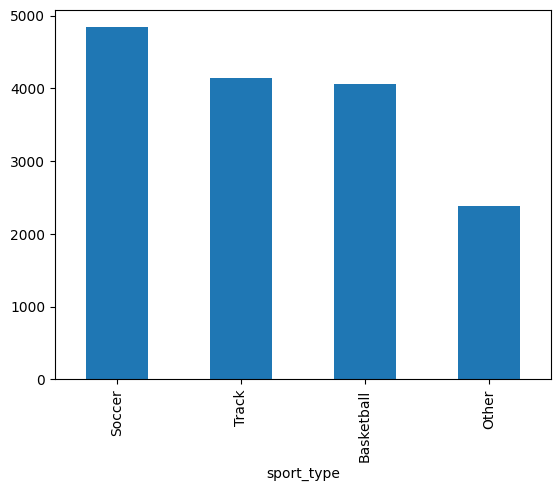

In [12]:
df['sport_type'].value_counts().plot(kind = 'bar')

In [13]:
df.describe()

,athlete_id,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,...,altitude,playing_surface,training_intensity,training_duration,training_load,fatigue_index,injury_occurred,session_id,age,bmi
count,15420.000000,15066.000000,15420.000000,15035.000000,14927.000000,15420.000000,15420.000000,14850.000000,15420.000000,14989.000000,...,15420.000000,15420.000000,14788.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,78.547601,72.688277,37.106443,78.036991,5.817429,55.202220,0.422916,247.724105,112.464607,1.864699,...,297.357416,2.019326,6.399174,87.790419,670.534269,59.698315,0.510117,49.926719,23.953567,23.138679
std,45.070131,17.758991,0.594843,11.848363,1.814602,17.326338,0.173425,126.930007,30.367148,0.603927,...,212.351977,1.409120,1.730882,27.628191,328.288466,25.196238,0.741662,28.540223,3.883533,2.301192
min,1.000000,40.000000,35.800000,45.000000,1.155807,8.902584,0.100000,10.000000,45.000000,0.800000,...,0.000000,0.000000,2.000000,30.000000,150.000000,15.000000,0.000000,1.000000,18.000000,18.500000
25%,39.000000,60.097967,36.698612,69.879145,4.510581,42.321722,0.300472,159.150375,91.437246,1.430372,...,127.750679,1.000000,5.208488,68.768634,426.148857,41.717110,0.000000,25.000000,21.000000,21.609635
50%,79.000000,72.304051,37.107090,78.165927,5.755650,54.421403,0.421168,245.496682,112.548535,1.854269,...,284.172663,2.000000,6.411926,87.835380,645.225337,57.340187,0.000000,50.000000,24.000000,22.988013
75%,118.000000,84.812895,37.512165,86.498440,7.068894,67.375690,0.543678,334.039698,133.960070,2.281691,...,442.388486,3.000000,7.597567,106.696365,879.607967,75.186924,1.000000,75.000000,27.000000,24.817666
max,156.000000,159.270125,39.200000,100.000000,10.000000,98.000000,0.950000,722.542819,175.000000,3.500000,...,1200.000000,4.000000,10.000000,180.000000,2632.637547,270.193219,2.000000,101.000000,34.000000,28.300000


In [14]:
df.isnull().sum()

athlete_id                 0
heart_rate               354
body_temperature           0
hydration_level          385
sleep_quality            493
recovery_score             0
stress_level               0
muscle_activity          570
joint_angles               0
gait_speed               431
cadence                    0
step_count                 0
jump_height                0
ground_reaction_force      0
range_of_motion            0
ambient_temperature        0
humidity                   0
altitude                   0
playing_surface            0
training_intensity       632
training_duration          0
training_load              0
fatigue_index              0
injury_occurred            0
session_id                 0
sport_type                 0
gender                     0
age                        0
bmi                        0
dtype: int64

In [15]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [16]:
df.isnull().sum()

athlete_id               0
heart_rate               0
body_temperature         0
hydration_level          0
sleep_quality            0
recovery_score           0
stress_level             0
muscle_activity          0
joint_angles             0
gait_speed               0
cadence                  0
step_count               0
jump_height              0
ground_reaction_force    0
range_of_motion          0
ambient_temperature      0
humidity                 0
altitude                 0
playing_surface          0
training_intensity       0
training_duration        0
training_load            0
fatigue_index            0
injury_occurred          0
session_id               0
sport_type               0
gender                   0
age                      0
bmi                      0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

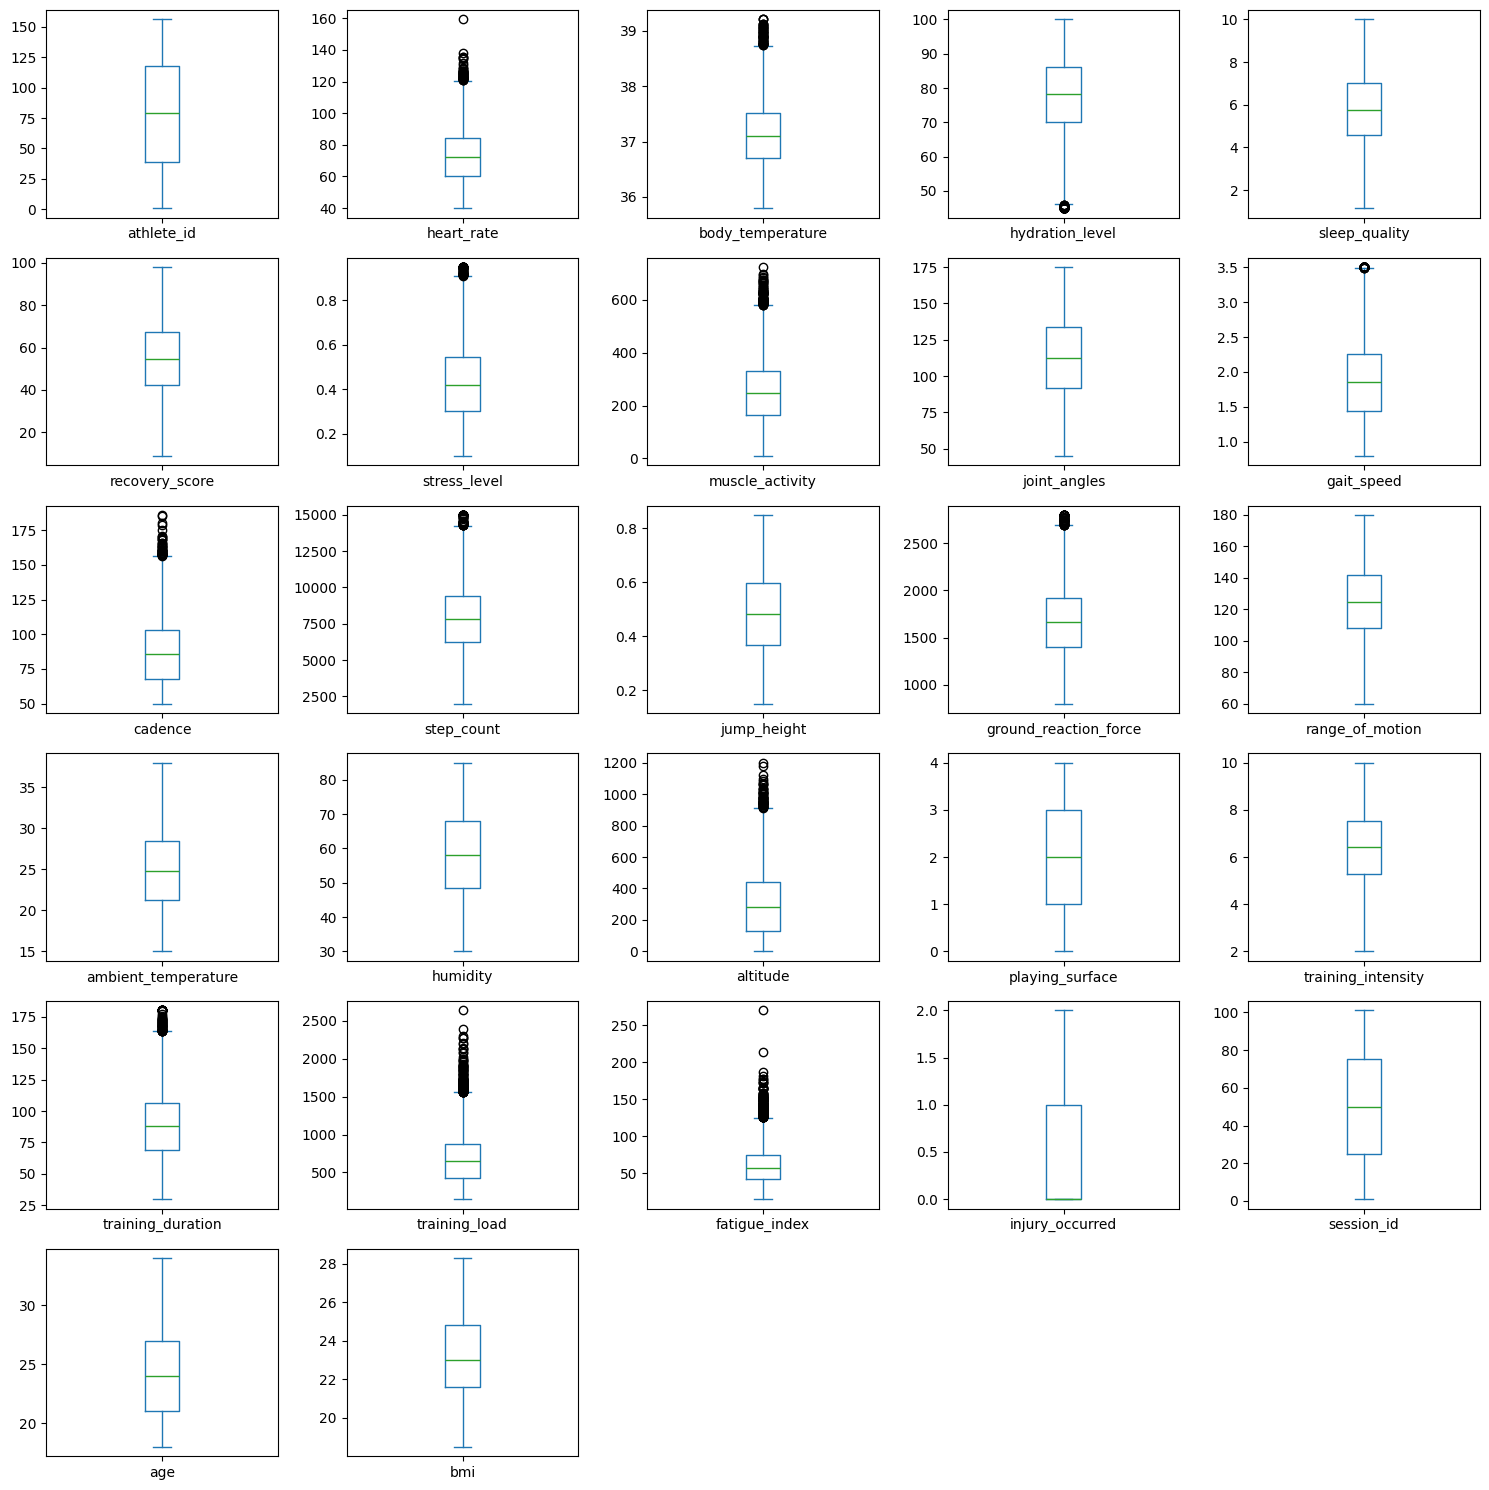

In [18]:
num_cols = df.select_dtypes(include='number').columns

df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(6,5),
    figsize=(15,15),
    sharex=False
)

plt.tight_layout()
plt.show()

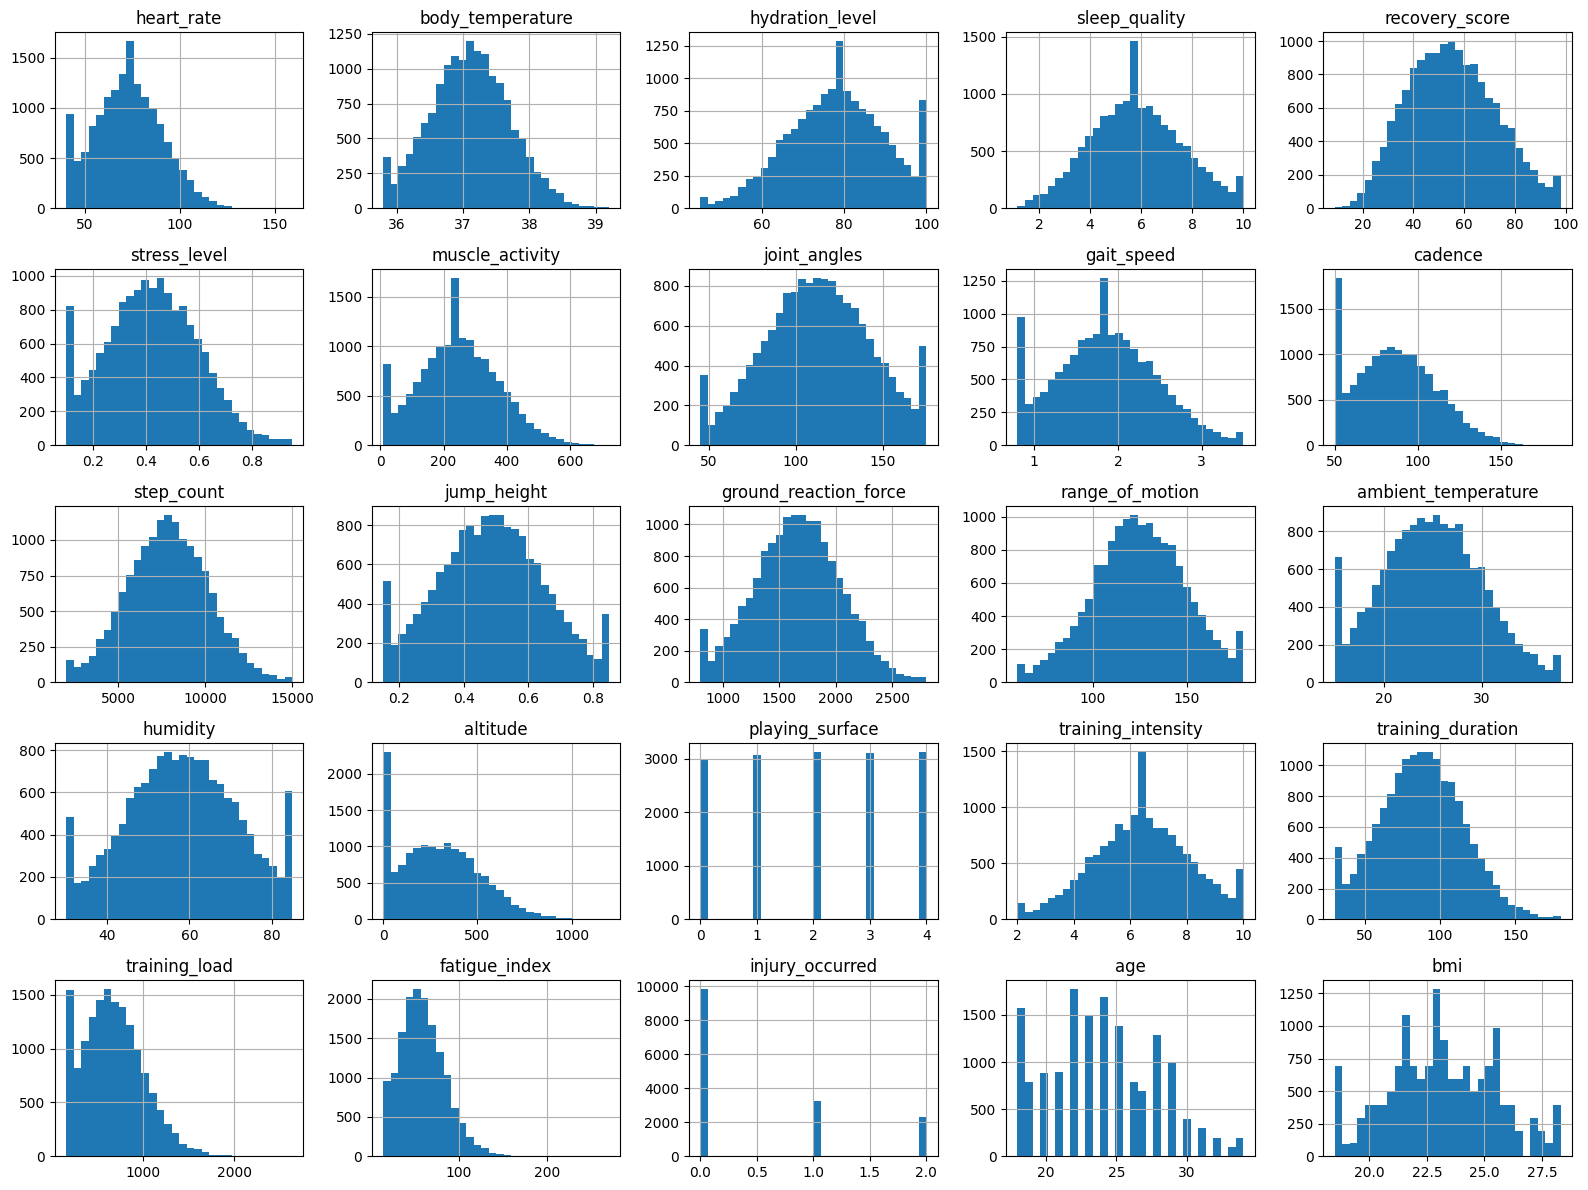

In [19]:
df_no_id = df.drop(columns=["athlete_id", "session_id"])

df_no_id.hist(figsize=(16,12), bins=30)
plt.tight_layout()
plt.show()

In [20]:

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop(['injury_occurred', 'athlete_id', 'session_id'])

transformer = PowerTransformer(method='yeo-johnson')

df_clean = df.copy()

df_clean[numeric_cols] = transformer.fit_transform(df[numeric_cols])

print(df_clean[numeric_cols].head())

   heart_rate  body_temperature  hydration_level  sleep_quality  \
0    0.021218         -0.079618        -0.158099      -0.168981   
1   -1.992461         -0.281425        -0.506555       0.621298   
2    0.238849         -1.310756         1.943427       2.026083   
3    1.530516          0.248972         0.685758       1.004988   
4    0.340219         -1.002392         0.423129      -0.075990   

   recovery_score  stress_level  muscle_activity  joint_angles  gait_speed  \
0        1.275322     -0.238537        -2.158802      0.465257    1.295957   
1        1.118307     -0.818158         0.534011      1.480340    2.414378   
2        1.560009     -0.485985        -0.664243     -1.009930   -1.911702   
3        1.380437     -1.193305        -1.118907      0.023858   -0.208874   
4        0.151531      0.383324        -0.616067      0.016986    0.520119   

    cadence  ...  ambient_temperature  humidity  altitude  playing_surface  \
0 -1.689885  ...            -1.467830 -0.801049 -1

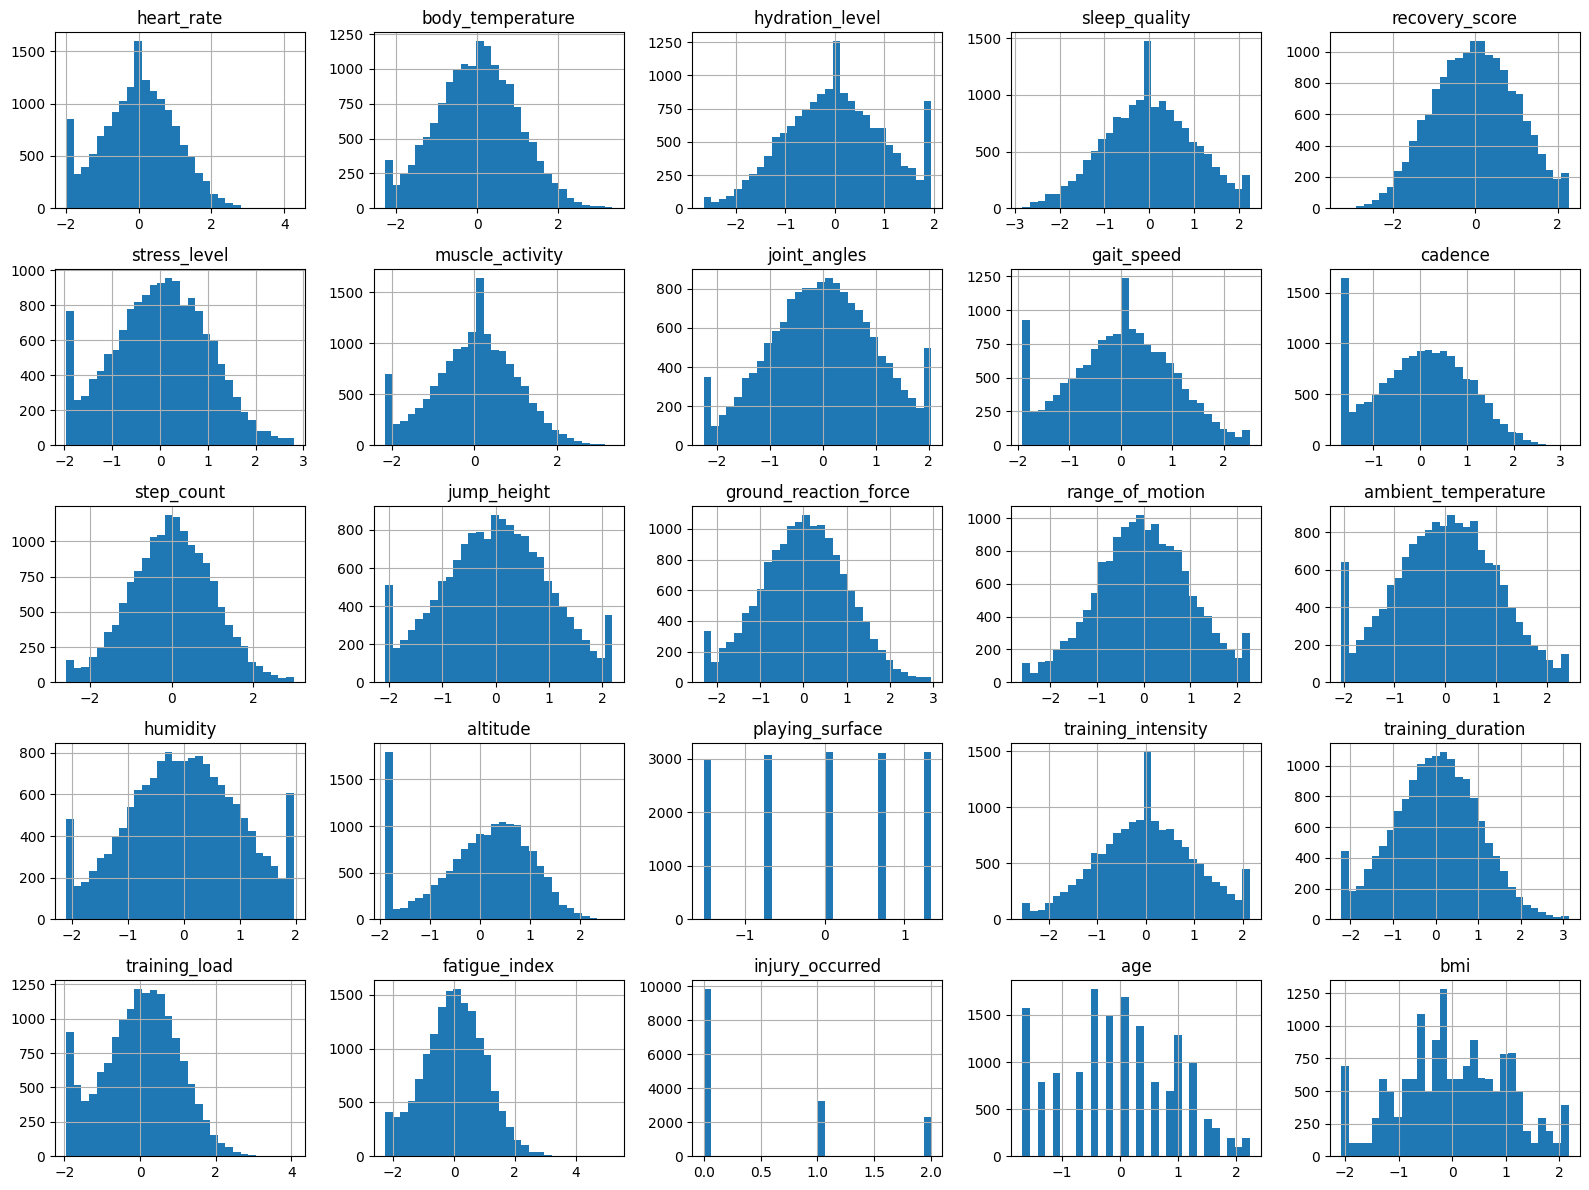

In [21]:
df_no_i = df_clean.drop(columns=["athlete_id", "session_id"], axis=1)
df_no_i.hist(figsize=(16,12), bins=30)
plt.tight_layout()
plt.show()

In [22]:
df = df_no_i

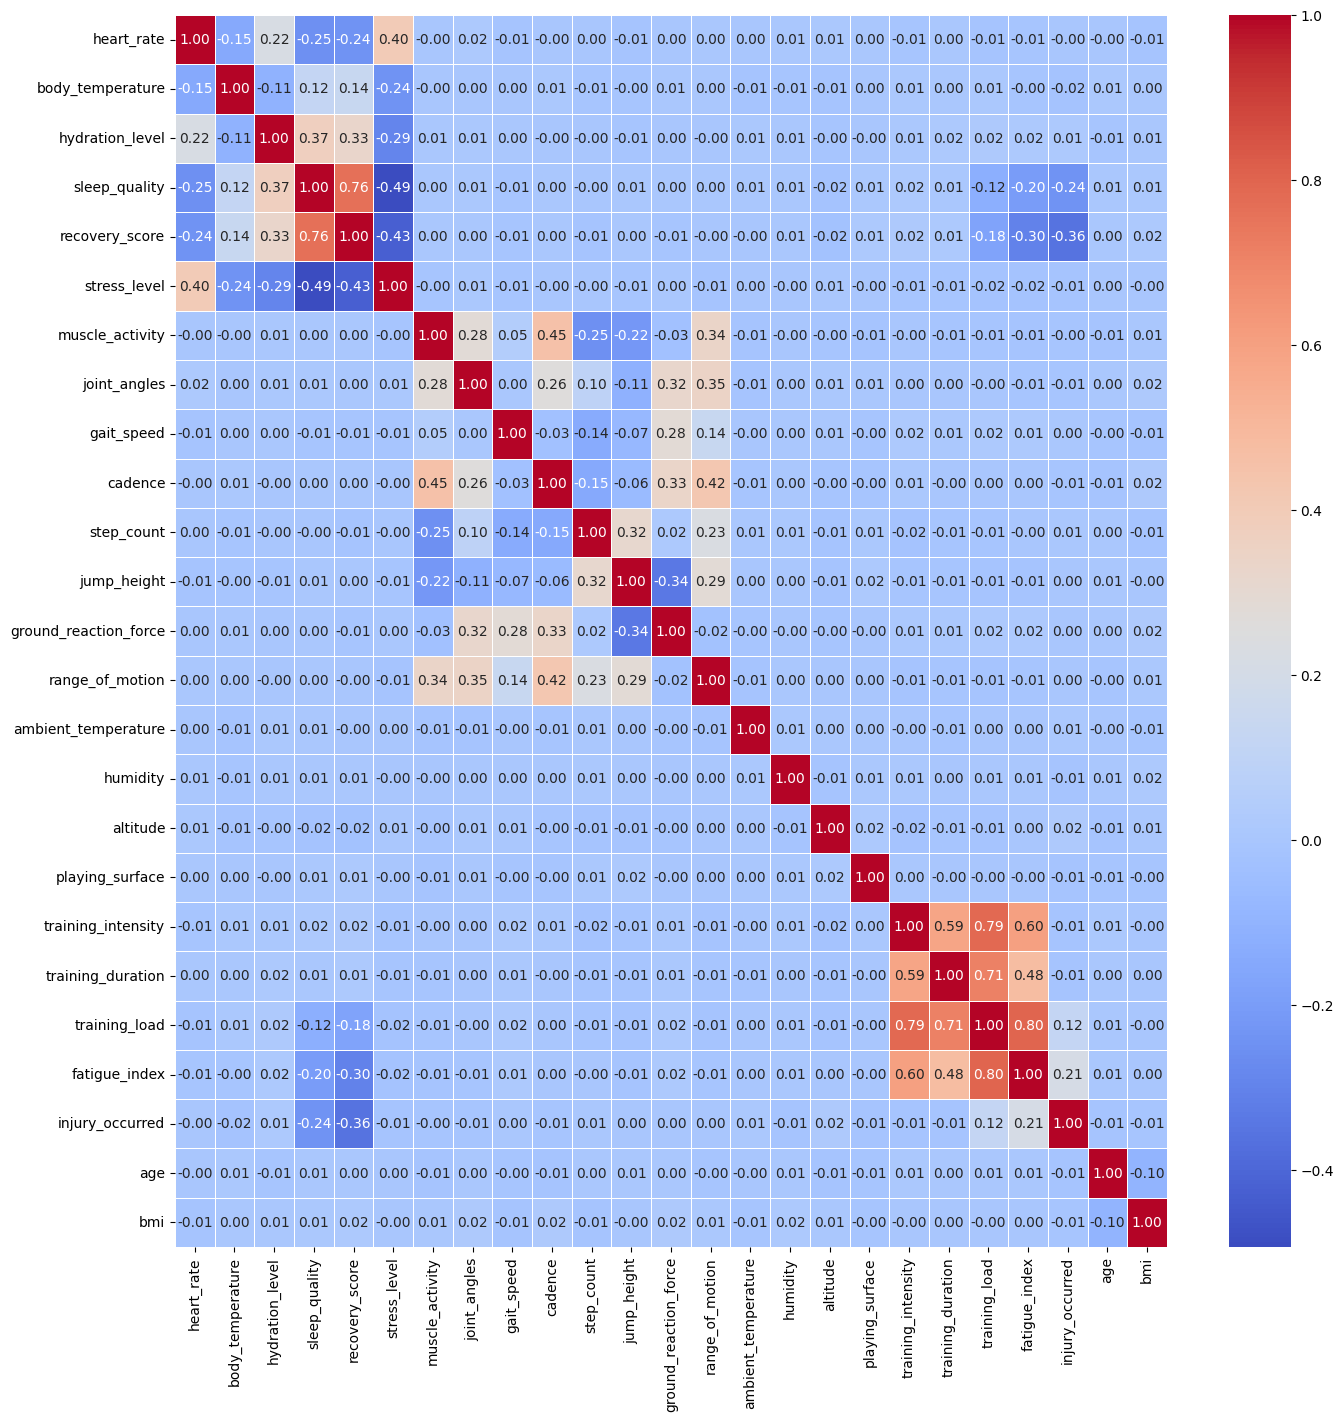

In [23]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

In [24]:
df[["gender","sport_type"]]

,gender,sport_type
0,Female,Basketball
1,Female,Basketball
2,Female,Basketball
3,Female,Basketball
4,Female,Basketball
...,...,...
15415,Female,Basketball
15416,Female,Track
15417,Male,Basketball
15418,Female,Track


In [25]:
onehot = OneHotEncoder(sparse_output=False)

In [26]:
encoded = onehot.fit_transform(df[["sport_type"]])
encoded_df = pd.DataFrame(encoded, columns=onehot.get_feature_names_out(["sport_type"]))
df = df.drop("sport_type", axis=1)
df = pd.concat([df, encoded_df], axis=1)# copier coller flekher

In [27]:
encoder = LabelEncoder()
df["gender"] = encoder.fit_transform(df["gender"])

In [28]:
df.head()

,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,cadence,...,training_load,fatigue_index,injury_occurred,gender,age,bmi,sport_type_Basketball,sport_type_Other,sport_type_Soccer,sport_type_Track
0,0.021218,-0.079618,-0.158099,-0.168981,1.275322,-0.238537,-2.158802,0.465257,1.295957,-1.689885,...,-0.254817,-0.503396,0,0,-1.685808,0.859169,1.0,0.0,0.0,0.0
1,-1.992461,-0.281425,-0.506555,0.621298,1.118307,-0.818158,0.534011,1.480340,2.414378,0.183191,...,-0.288904,-0.632279,2,0,-1.685808,0.859169,1.0,0.0,0.0,0.0
2,0.238849,-1.310756,1.943427,2.026083,1.560009,-0.485985,-0.664243,-1.009930,-1.911702,-0.499516,...,0.056954,0.200512,0,0,-1.685808,0.859169,1.0,0.0,0.0,0.0
3,1.530516,0.248972,0.685758,1.004988,1.380437,-1.193305,-1.118907,0.023858,-0.208874,-1.689885,...,-1.029667,-0.271095,0,0,-1.685808,0.859169,1.0,0.0,0.0,0.0
4,0.340219,-1.002392,0.423129,-0.075990,0.151531,0.383324,-0.616067,0.016986,0.520119,-0.582564,...,-0.430186,-1.308505,2,0,-1.685808,0.859169,1.0,0.0,0.0,0.0


In [29]:
df['injury_occurred'] = df['injury_occurred'].replace({2: 1})

In [30]:
df['injury_occurred'].value_counts()

injury_occurred
0    9868
1    5552
Name: count, dtype: int64

In [31]:
# FEATURE ENGINEERING
df['fatigue_recovery_ratio'] = df['fatigue_index'] / df['recovery_score']

df['sleep_stress_index'] = df['stress_level'] / df['sleep_quality']

In [32]:
X = df.drop('injury_occurred',axis=1)
y = df['injury_occurred']

**P(Injury∣fatigue_index>threshold)**

In [33]:
# =============================================================================
# BAYES THEOREM - MANUAL INTERPRETATION
# Example: Probability of injury if fatigue_index > threshold
# =============================================================================

threshold = df['fatigue_index'].mean()

# Dataset size
N_total = len(df)

# Injury counts
N_injury = (df['injury_occurred'] == 1).sum()
N_noinjury = (df['injury_occurred'] == 0).sum()

# PRIOR PROBABILITIES
P_injury = N_injury / N_total
P_noinjury = N_noinjury / N_total

# LIKELIHOODS
P_F_I = (df[df['injury_occurred'] == 1]['fatigue_index'] > threshold).mean()

P_F_NI = (df[df['injury_occurred'] == 0]['fatigue_index'] > threshold).mean()

# EVIDENCE
P_F = P_F_I * P_injury + P_F_NI * P_noinjury

# POSTERIOR
P_I_given_F = (P_F_I * P_injury) / P_F
P_NI_given_F = (P_F_NI * P_noinjury) / P_F


print("===================================")
print("BAYES INTERPRETATION - INJURY RISK")
print("===================================")

print(f"P(Injury) = {P_injury*100:.3f}% of players experienced an injury")
print(f"P(No Injury) = {P_noinjury*100:.3f} did not experience an injury")

print(f"P(Fatigue > {threshold:.2f} | Injury) = {P_F_I*100:.3f}% of injured players had fatigue above the threshold") 
print(f"P(Fatigue > {threshold:.2f} | No Injury) = {P_F_NI*100:.3f}% of healthy players also had high fatigue")
print("High fatigue appears more frequently in injured players than in non-injured players, suggesting it may contribute to injury risk.")

print("core result of Bayes’ theorem:")
print(f"P(Injury | Fatigue > {threshold:.2f}) = {P_I_given_F:.3f}")
print(f"wich means that if a player has a fatigue index above the threshold, they have approximately a {P_I_given_F*100:.1f}% chance of being injured based on the data.")
# Fatigue > -0.00 =  fatigue_index > average fatigue = Players with fatigue above the average level.
print(f"\nIf fatigue_index > {threshold:.2f}, injury probability = {P_I_given_F*100:.1f}%")

BAYES INTERPRETATION - INJURY RISK
P(Injury) = 36.005% of players experienced an injury
P(No Injury) = 63.995 did not experience an injury
P(Fatigue > -0.00 | Injury) = 57.691% of injured players had fatigue above the threshold
P(Fatigue > -0.00 | No Injury) = 47.051% of healthy players also had high fatigue
High fatigue appears more frequently in injured players than in non-injured players, suggesting it may contribute to injury risk.
core result of Bayes’ theorem:
P(Injury | Fatigue > -0.00) = 0.408
wich means that if a player has a fatigue index above the threshold, they have approximately a 40.8% chance of being injured based on the data.

If fatigue_index > -0.00, injury probability = 40.8%


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Original training dataset shape: {Counter(y_train)}")

Original training dataset shape: Counter({0: 7894, 1: 4442})


In [35]:
nb_model = GaussianNB()
knn_model = KNeighborsClassifier(n_neighbors=5)

In [36]:
nb_model.fit(X_train, y_train)

GaussianNB()

In [37]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [38]:
nb_predictions = nb_model.predict(X_test)
knn_predictions = knn_model.predict(X_test)

In [39]:
print("\n" + "="*40)
print("🏆 RESULTS: NAIVE BAYES 🏆")
print("="*40)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Overall Accuracy: {nb_accuracy * 100:.2f} %\n")
print("Detailed Report (Naive Bayes):")
print(classification_report(y_test, nb_predictions))

# --- KNN RESULTS ---
print("\n" + "="*40)
print("🏆 RESULTS: KNN (k=5) 🏆")
print("="*40)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"Overall Accuracy: {knn_accuracy * 100:.2f} %\n")
print("Detailed Report (KNN):")
print(classification_report(y_test, knn_predictions))


🏆 RESULTS: NAIVE BAYES 🏆
Overall Accuracy: 65.60 %

Detailed Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.67      0.93      0.77      1974
           1       0.57      0.18      0.27      1110

    accuracy                           0.66      3084
   macro avg       0.62      0.55      0.52      3084
weighted avg       0.63      0.66      0.59      3084


🏆 RESULTS: KNN (k=5) 🏆
Overall Accuracy: 62.52 %

Detailed Report (KNN):
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1974
           1       0.47      0.33      0.39      1110

    accuracy                           0.63      3084
   macro avg       0.57      0.56      0.56      3084
weighted avg       0.60      0.63      0.61      3084



### Analyse des premiers résultats
Bien que notre premier modèle affiche une précision globale (Accuracy) d'environ 65 %, une lecture attentive du rapport de classification (Classification Report) révèle un problème majeur : le **Rappel (Recall)** pour la classe 1 (Blessures) est très faible. 

**Pourquoi ce score ?** Notre jeu de données est naturellement déséquilibré (64 % de non-blessés contre 36 % de blessés). Par conséquent, le modèle adopte un comportement "paresseux" : il a tendance à prédire majoritairement la classe "0" (Pas de blessure) pour maximiser son score global, ignorant ainsi une grande partie des véritables blessures. Dans un contexte sportif et médical, manquer la détection d'une blessure est dangereux.

**La solution envisagée :**
Pour corriger ce biais, nous allons utiliser la technique **SMOTE** dans la prochaine étape.

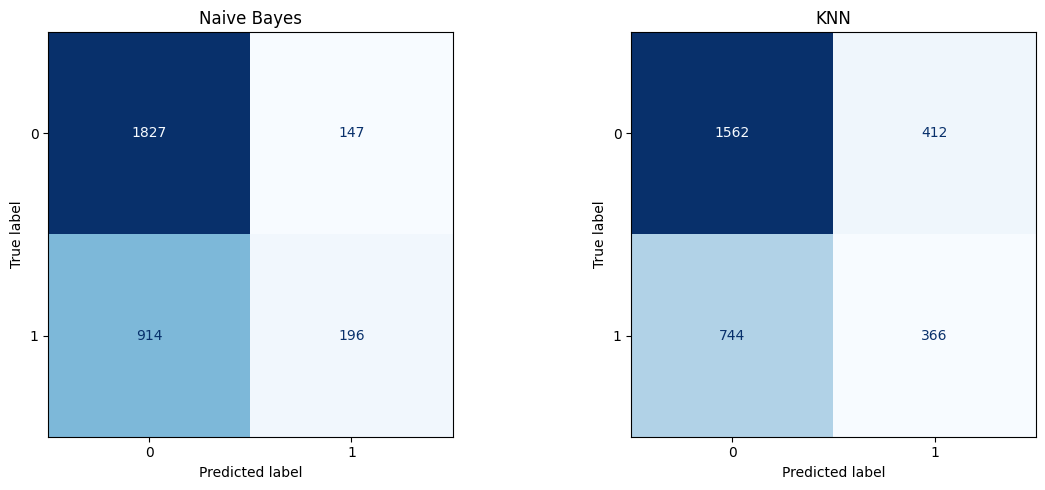

In [40]:
nb_conf_matrix = confusion_matrix(y_test, nb_predictions)
knn_conf_matrix = confusion_matrix(y_test, knn_predictions)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nb_disp = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
nb_disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Bayes')

knn_disp = ConfusionMatrixDisplay(confusion_matrix=knn_conf_matrix)
knn_disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('KNN')

plt.tight_layout()
plt.show()

### Équilibrage des données avec SMOTE
Pour forcer nos algorithmes à prendre la classe minoritaire au sérieux, nous allons appliquer **SMOTE** (Synthetic Minority Over-sampling Technique). 

**Comment ça marche ?**
Au lieu de simplement dupliquer des lignes (ce qui causerait de l'overfitting), SMOTE génère de nouveaux profils d'athlètes blessés de manière synthétique et réaliste, en se basant sur les voisins les plus proches. 
*Note importante :* Nous appliquons SMOTE **uniquement sur les données d'entraînement (`X_train`)** pour obtenir une répartition parfaite de 50/50, tout en gardant nos données de test (`X_test`) intactes pour évaluer le modèle dans des conditions réelles.

In [41]:
smote = SMOTE(random_state=42)
X_train_equilibres, y_train_equilibres = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {y_train_equilibres.value_counts().to_dict()} (Parfaitement 50/50 !)\n")


Avant SMOTE : {0: 7894, 1: 4442}
Après SMOTE : {0: 7894, 1: 7894} (Parfaitement 50/50 !)



In [42]:
n_bayes = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5) 
n_bayes.fit(X_train_equilibres, y_train_equilibres)


GaussianNB()

In [43]:
knn.fit(X_train_equilibres, y_train_equilibres)

KNeighborsClassifier()

In [44]:
nb_prediction = n_bayes.predict(X_test)
knn_prediction = knn.predict(X_test)

In [45]:
print("\n" + "="*40)
print("🏆 NOUVEAUX RÉSULTATS : NAIVE BAYES 🏆")
print("="*40)
print(f"Accuracy globale : {accuracy_score(y_test, nb_prediction) * 100:.2f} %\n")
print(classification_report(y_test, nb_prediction))

print("\n" + "="*40)
print("🏆 NOUVEAUX RÉSULTATS : KNN (k=5) 🏆")
print("="*40)
print(f"Accuracy globale : {accuracy_score(y_test, knn_prediction) * 100:.2f} %\n")
print(classification_report(y_test, knn_prediction))


🏆 NOUVEAUX RÉSULTATS : NAIVE BAYES 🏆
Accuracy globale : 64.53 %

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1974
           1       0.51      0.39      0.44      1110

    accuracy                           0.65      3084
   macro avg       0.60      0.59      0.59      3084
weighted avg       0.63      0.65      0.63      3084


🏆 NOUVEAUX RÉSULTATS : KNN (k=5) 🏆
Accuracy globale : 53.92 %

              precision    recall  f1-score   support

           0       0.70      0.48      0.57      1974
           1       0.41      0.64      0.50      1110

    accuracy                           0.54      3084
   macro avg       0.56      0.56      0.54      3084
weighted avg       0.60      0.54      0.55      3084



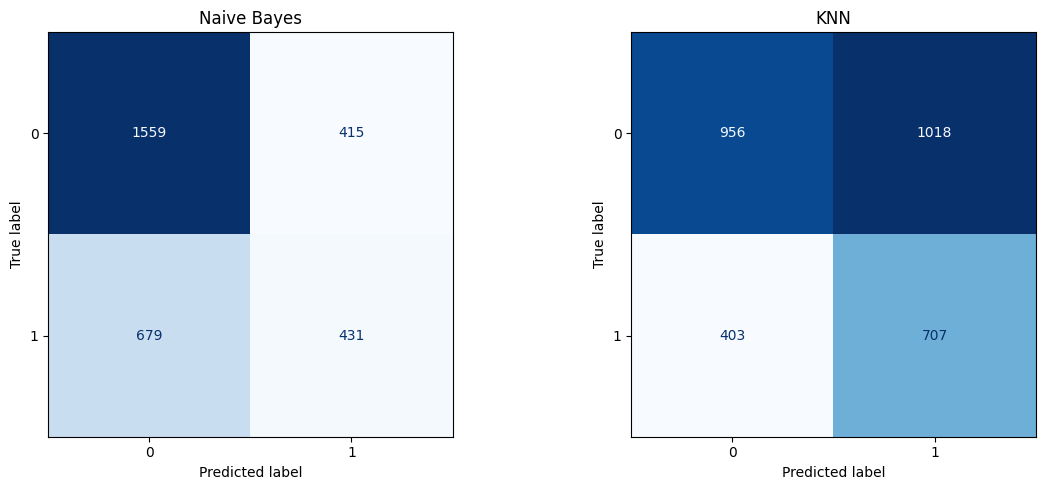

In [46]:
nb_conf_matrix = confusion_matrix(y_test, nb_prediction)
knn_conf_matrix = confusion_matrix(y_test, knn_prediction)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

nb_disp = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
nb_disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Bayes')

knn_disp = ConfusionMatrixDisplay(confusion_matrix=knn_conf_matrix)
knn_disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('KNN')

plt.tight_layout()
plt.show()

### Sélection des variables fortes (Feature Selection)
L'algorithme **K-Nearest Neighbors (KNN)** est très sensible à ce qu'on appelle le "fléau de la dimension" (Curse of Dimensionality). Puisqu'il calcule la distance physique entre les points de données, la présence de variables non pertinentes crée du "bruit" qui fausse ces calculs de distance.

Pour aider le KNN à se concentrer, nous allons filtrer notre jeu de données et ne conserver que les variables (features) ayant les plus fortes corrélations avec l'apparition des blessures (comme la fatigue, le score de récupération, la charge d'entraînement, etc.).

In [47]:

strong_features = [
    'fatigue_recovery_ratio', 
    'recovery_score', 
    'fatigue_index', 
    'training_load',
    'sleep_quality'

]

X_train_strong = X_train[strong_features]
X_test_strong = X_test[strong_features]

smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_strong, y_train)


knn_ultimate = KNeighborsClassifier(n_neighbors=15, weights='distance')
knn_ultimate.fit(X_train_final, y_train_final)

ultimate_predictions = knn_ultimate.predict(X_test_strong)

print("\n" + "="*50)
print("🏆 RESULTS: THE ULTIMATE KNN MODEL 🏆")
print("(Strong Features + SMOTE + Distance Weights)")
print("="*50)
print(f"Overall Accuracy: {accuracy_score(y_test, ultimate_predictions) * 100:.2f} %\n")
print(classification_report(y_test, ultimate_predictions))


🏆 RESULTS: THE ULTIMATE KNN MODEL 🏆
(Strong Features + SMOTE + Distance Weights)
Overall Accuracy: 58.50 %

              precision    recall  f1-score   support

           0       0.71      0.60      0.65      1974
           1       0.44      0.56      0.49      1110

    accuracy                           0.58      3084
   macro avg       0.57      0.58      0.57      3084
weighted avg       0.61      0.58      0.59      3084



### Optimisation automatisée avec GridSearchCV
Jusqu'à présent, nous avons réglé les paramètres de notre modèle (comme le nombre de voisins $k$) de manière empirique. Pour obtenir la meilleure version possible de notre modèle KNN, nous allons utiliser **GridSearchCV**. 

**Description de l'outil :**
GridSearchCV va automatiser la recherche des hyperparamètres optimaux. Nous allons lui fournir une "grille" de valeurs à tester (différents $k$, différentes méthodes de pondération et de calcul de distance). Il va tester **toutes les combinaisons possibles** en utilisant la technique de **Validation Croisée (Cross-Validation)** pour s'assurer que le résultat est robuste et éviter le surapprentissage. 

L'objectif (scoring) demandé à la grille sera de maximiser le **Recall** afin de privilégier la détection des blessures.

In [48]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 21, 25], 
    'weights': ['uniform', 'distance'],              
    'metric': ['euclidean', 'manhattan']            
}

knn_base = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn_base, param_grid=param_grid, cv=5, scoring='recall', verbose=1)

print("Lancement de GridSearchCV... l'ordinateur travaille !")
grid_search.fit(X_train_final, y_train_final) 

print("\n" + "="*50)
print("🏆 LES MEILLEURS PARAMÈTRES ABSOLUS SONT : 🏆")
print("="*50)
print(grid_search.best_params_)

Lancement de GridSearchCV... l'ordinateur travaille !
Fitting 5 folds for each of 36 candidates, totalling 180 fits

🏆 LES MEILLEURS PARAMÈTRES ABSOLUS SONT : 🏆
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


L'algorithme GridSearchCV a identifié que la meilleure configuration mathématique pour nos données est un KNN avec **3 voisins**, pondéré par la **distance euclidienne**.

In [49]:
knn_parfait = grid_search.best_estimator_

predictions_finales = knn_parfait.predict(X_test_strong)

print("\n" + "="*50)
print("🏆 LE RÉSULTAT FINAL DU PROJET (KNN OPTIMISÉ) 🏆")
print("="*50)
print(f"Accuracy Globale : {accuracy_score(y_test, predictions_finales) * 100:.2f} %\n")
print("Rapport de Performance Détaillé :")
print(classification_report(y_test, predictions_finales))


🏆 LE RÉSULTAT FINAL DU PROJET (KNN OPTIMISÉ) 🏆
Accuracy Globale : 56.74 %

Rapport de Performance Détaillé :
              precision    recall  f1-score   support

           0       0.69      0.59      0.64      1974
           1       0.42      0.53      0.47      1110

    accuracy                           0.57      3084
   macro avg       0.56      0.56      0.55      3084
weighted avg       0.59      0.57      0.58      3084



### Conclusion des performances du modèle optimal

**Analyse du résultat final :**
Le modèle optimal affiche une précision globale de ~57 %. Plus important encore, son **Recall pour les blessures est monté à 53 %**. 
Bien que l'Accuracy globale ait baissé par rapport au tout premier modèle paresseux, ce nouveau modèle est infiniment plus utile en pratique : il est désormais capable de détecter correctement plus de la moitié des risques de blessures réels. Nous avons réussi à transformer un modèle mathématiquement biaisé en un outil préventif fonctionnel et axé sur la sécurité des athlètes.

In [50]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



# ==========================================
# OPTION A & STEP 4: Decision Tree Training & Evaluation
# ==========================================
dt_model_unlim = DecisionTreeClassifier(random_state=42)
dt_model_unlim.fit(X_train, y_train)

dt_predictions = dt_model_unlim.predict(X_test)
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_predictions))

# ==========================================
# OPTION B & STEP 4: Random Forest Training & Evaluation
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced' ,random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
print("\nBase Random Forest Classification Report:\n", classification_report(y_test, rf_predictions))

# ==========================================
# STEP 5: Hyperparameter Tuning (On Random Forest)
# ==========================================
print("\n--- Step 5: Hyperparameter Tuning (Grid Search) ---")
# Define the parameters we want to test
param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'n_estimators':[10, 20]
}

# Run the search (cv=5 means 5-fold cross-validation, n_jobs=-1 uses all CPU cores)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

# Save the best model found by GridSearch
best_rf_model = grid_search.best_estimator_

print("Best Parameters Found:", grid_search.best_params_)
tuned_predictions = best_rf_model.predict(X_test)
print("\nTuned Random Forest Accuracy:", accuracy_score(y_test, tuned_predictions))


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.67      0.66      0.67      1974
           1       0.42      0.44      0.43      1110

    accuracy                           0.58      3084
   macro avg       0.55      0.55      0.55      3084
weighted avg       0.58      0.58      0.58      3084


Base Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.91      0.78      1974
           1       0.62      0.25      0.36      1110

    accuracy                           0.67      3084
   macro avg       0.65      0.58      0.57      3084
weighted avg       0.66      0.67      0.63      3084


--- Step 5: Hyperparameter Tuning (Grid Search) ---
Best Parameters Found: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 20}

Tuned Random Forest Accuracy: 0.6783398184176395


**Random Forest (68%) perform better than the Decision Tree (58%).**

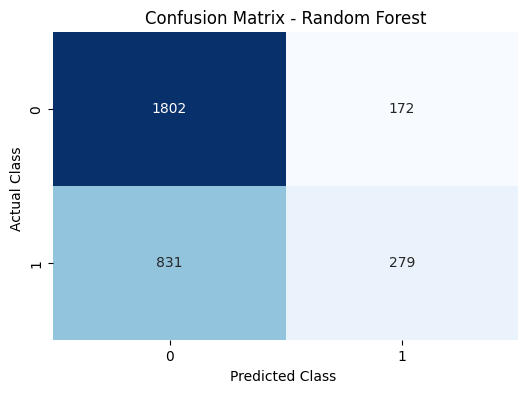

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Class ')
plt.ylabel('Actual Class ')
plt.show()

**The model is biased toward the majority class. It successfully caught 484 Class 1 events but missed 626 of them.**

In [52]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Made the canvas massively wide (50, 20) instead of (30, 15)
plt.figure(figsize=(50, 20), dpi=300) 

plot_tree(dt_model_unlim, 
          feature_names=X.columns, 
          class_names=['Class 0', 'Class 1'], 
          filled=True, 
          rounded=True, 
          max_depth=3,  # 2. Lowered to 3. (Depth 4 usually has 16+ boxes on the bottom row!)
          fontsize=8)   # 3. Made font smaller so it stays inside the boxes

plt.title('Arbre de Décision ', fontsize=20)
plt.savefig('my_clean_decision_tree.png', bbox_inches='tight')
plt.show()

C:\Users\OULADKRIT\AppData\Local\Temp\ipykernel_21456\2920522344.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(5), palette='viridis')


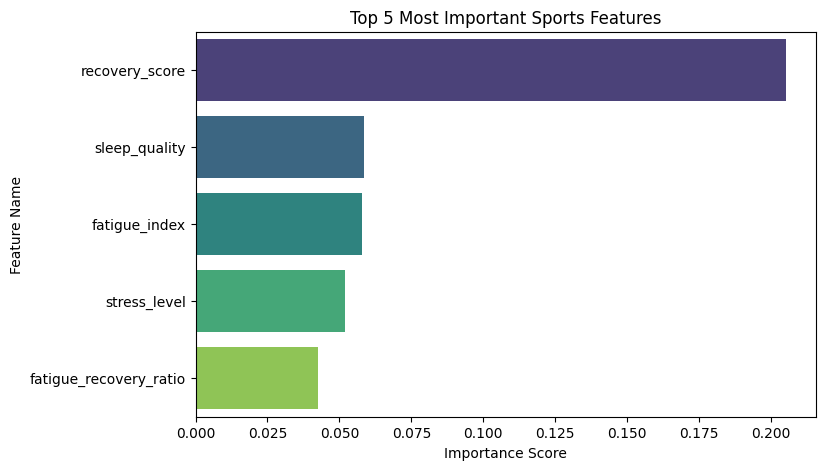

In [53]:
# 1. Extract feature importances from your trained model 
# (If you named your model something else like rf_model, change it here!)
importances = best_rf_model.feature_importances_

# 2. Create the missing DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. NOW plot the bar chart!
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(5), palette='viridis')
plt.title('Top 5 Most Important Sports Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

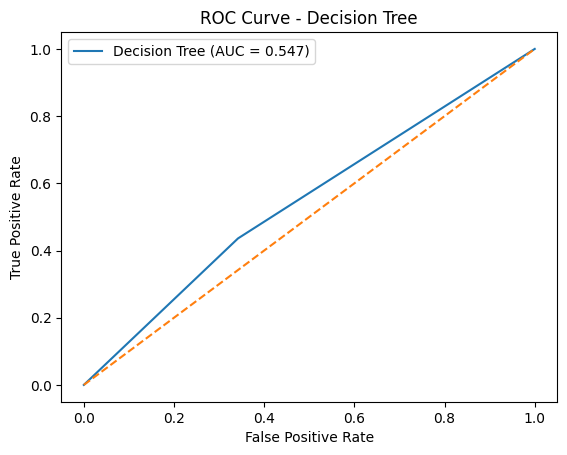

In [54]:
from sklearn.metrics import roc_curve, auc

# Get probability scores (important for ROC)
y_proba_dt = dt_model_unlim.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

**The recovery_score is the ultimate predictor of an athlete's status. It drives the AI's decisions more than any other metric.**

In [55]:
# =============================================================================
# SECTION 1 — ARBRE DE DÉCISION (Decision Tree limité à une profondeur de 3 pour la visualisation)


  SECTION 1 : ARBRE DE DÉCISION (DT)
  Accuracy  : 65.86%
  F-score   : 0.3788
  Recall    : 0.2892
  FPR       : 0.1337
  Log Loss  : 1.2286
  RMSLE     : 0.4050


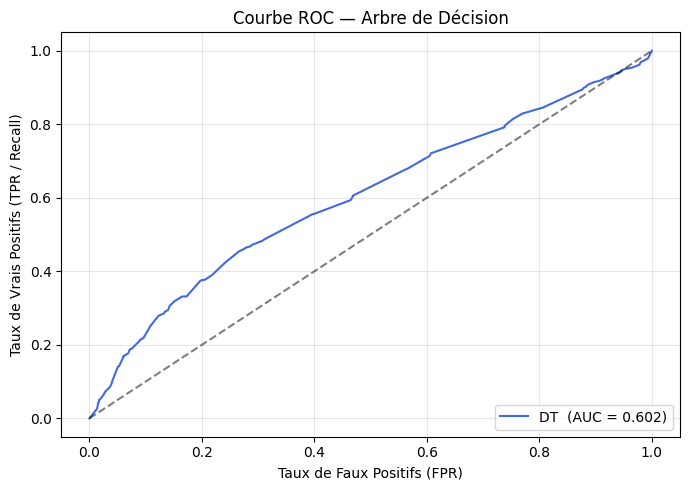

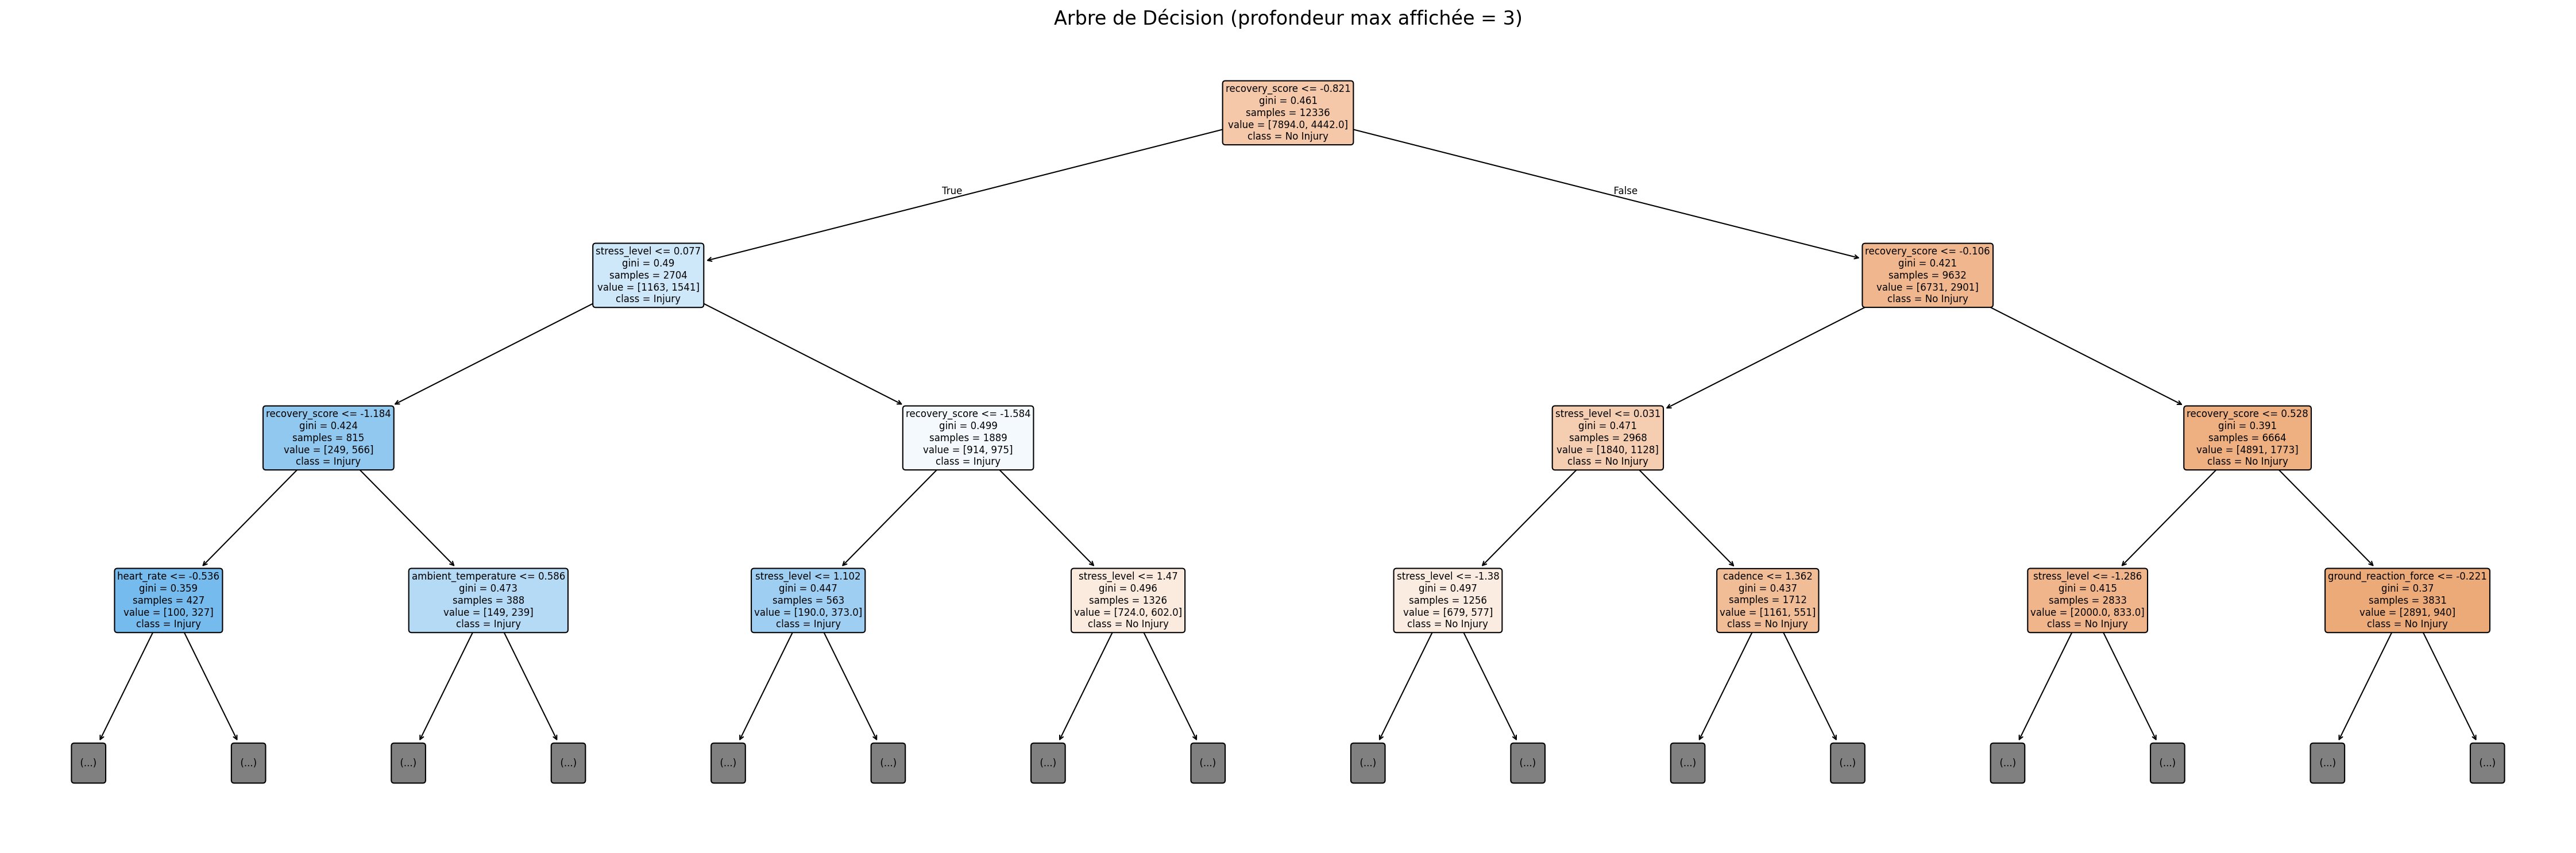

In [56]:
# =============================================================================
print("\n" + "="*60)
print("  SECTION 1 : ARBRE DE DÉCISION (DT)")
print("="*60)

dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred   = dt_model.predict(X_test)
dt_proba  = dt_model.predict_proba(X_test)

# — Métriques Classification —
dt_acc    = accuracy_score(y_test, dt_pred)
dt_f1     = f1_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
tn, fp, fn, tp = confusion_matrix(y_test, dt_pred).ravel()
dt_fpr    = fp / (fp + tn)

print(f"  Accuracy  : {dt_acc*100:.2f}%")
print(f"  F-score   : {dt_f1:.4f}")
print(f"  Recall    : {dt_recall:.4f}")
print(f"  FPR       : {dt_fpr:.4f}")

# — Métriques Probabilistes —
dt_logloss = log_loss(y_test, dt_proba)
y_test_safe = np.clip(y_test, 0, None)
dt_pred_safe = np.clip(dt_pred, 0, None)
dt_rmsle = np.sqrt(mean_squared_log_error(y_test_safe, dt_pred_safe))

print(f"  Log Loss  : {dt_logloss:.4f}")
print(f"  RMSLE     : {dt_rmsle:.4f}")

# — Courbe ROC & AUC —
dt_auc = roc_auc_score(y_test, dt_proba[:, 1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba[:, 1])

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f"DT  (AUC = {dt_auc:.3f})", color="royalblue")
plt.plot([0,1],[0,1], "k--", alpha=0.5)
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR / Recall)")
plt.title("Courbe ROC — Arbre de Décision")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# — Visualisation de l'arbre —
plt.figure(figsize=(30, 10), dpi=150)
plot_tree(dt_model, feature_names=X.columns, class_names=["No Injury","Injury"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Arbre de Décision (profondeur max affichée = 3)", fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
# =============================================================================
# ÉTAPE 2 — PARTIE A : Modèles supplémentaires + Métriques avancées
#  Markov-RF (Marbar-RF), Weibull, Benford

In [58]:
# =============================================================================
# SECTION 2 — MARBAR-RF (Random Forest avec pondération Markovienne)

# =============================================================================
# Principe : on construit un RF, puis on pondère les probabilités finales
# par une matrice de transition Markovienne inter-arbre (transition entre
# les prédictions consécutives dans l'ensemble), ce qui est la variante
# "Marbar" enseignée.


  SECTION 2 : MARBAR-RF (Random Forest + Pondération Markovienne)


C:\Users\OULADKRIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\OULADKRIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\OULADKRIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\OULADKRIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\OULADKRIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassi

  Matrice de Transition Markovienne (Marbar) :
  Lignes = état actuel, Colonnes = état suivant
              → 0     → 1
Prédit: 0  0.6647  0.3353
Prédit: 1  0.5996  0.4004

  Accuracy  : 64.01%
  F-score   : 0.0000
  Recall    : 0.0000
  FPR       : 0.0000
  Log Loss  : 0.6486
  RMSLE     : 0.4158


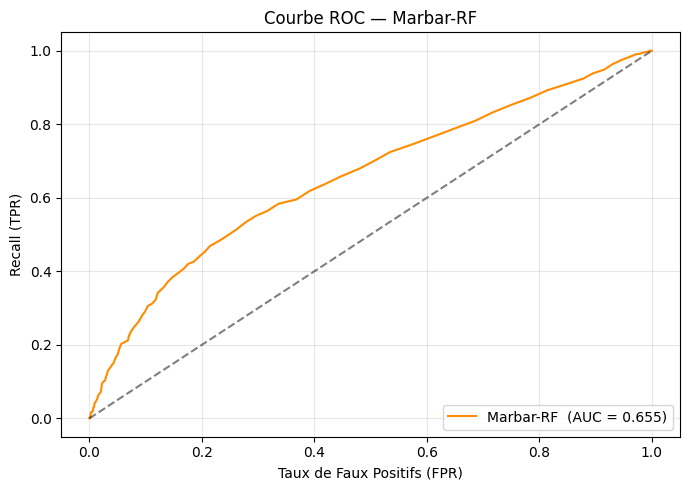

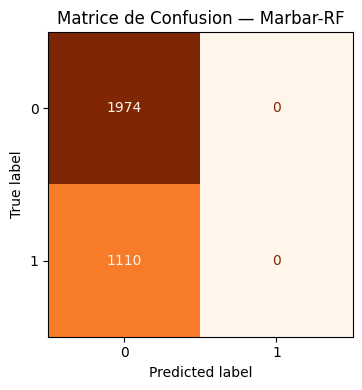

In [59]:
# =============================================================================
print("\n" + "="*60)
print("  SECTION 2 : MARBAR-RF (Random Forest + Pondération Markovienne)")
print("="*60)

# — 2a. Entraînement du Random Forest de base —
rf_base = RandomForestClassifier(n_estimators=150, class_weight="balanced",
                                  random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

# — 2b. Collecte des prédictions individuelles de chaque arbre —
tree_preds = np.array([tree.predict(X_test) for tree in rf_base.estimators_])
# shape: (n_estimators, n_samples)

# — 2c. Construction de la matrice de transition Markovienne —
# Transition entre l'arbre i et l'arbre i+1 : P(classe_j | classe_i)
n_classes = 2
transition_matrix = np.zeros((n_classes, n_classes))

for i in range(len(rf_base.estimators_) - 1):
    for j in range(len(X_test)):
        s = int(tree_preds[i, j])
        s_next = int(tree_preds[i+1, j])
        transition_matrix[s, s_next] += 1

# Normalisation (matrice stochastique)
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
transition_matrix /= row_sums

print("  Matrice de Transition Markovienne (Marbar) :")
print("  Lignes = état actuel, Colonnes = état suivant")
print(pd.DataFrame(transition_matrix,
                   index=["Prédit: 0","Prédit: 1"],
                   columns=["→ 0","→ 1"]).round(4).to_string(index=True))

# — 2d. Probabilités RF de base —
rf_proba_base = rf_base.predict_proba(X_test)  # shape: (n_samples, 2)

# — 2e. Pondération Markovienne : proba_marbar = proba_rf @ transition_matrix —
marbar_proba = rf_proba_base @ transition_matrix
marbar_pred  = np.argmax(marbar_proba, axis=1)

# — Métriques Classification —
mb_acc    = accuracy_score(y_test, marbar_pred)
mb_f1     = f1_score(y_test, marbar_pred)
mb_recall = recall_score(y_test, marbar_pred)
tn, fp, fn, tp = confusion_matrix(y_test, marbar_pred).ravel()
mb_fpr    = fp / (fp + tn)

print(f"\n  Accuracy  : {mb_acc*100:.2f}%")
print(f"  F-score   : {mb_f1:.4f}")
print(f"  Recall    : {mb_recall:.4f}")
print(f"  FPR       : {mb_fpr:.4f}")

# — Métriques Probabilistes —
mb_logloss = log_loss(y_test, marbar_proba)
y_test_safe = np.clip(y_test, 0, None)
mb_rmsle   = np.sqrt(mean_squared_log_error(y_test_safe, np.clip(marbar_pred, 0, None)))

print(f"  Log Loss  : {mb_logloss:.4f}")
print(f"  RMSLE     : {mb_rmsle:.4f}")

# — Courbe ROC & AUC —
mb_auc = roc_auc_score(y_test, marbar_proba[:, 1])
fpr_mb, tpr_mb, _ = roc_curve(y_test, marbar_proba[:, 1])

plt.figure(figsize=(7, 5))
plt.plot(fpr_mb, tpr_mb, label=f"Marbar-RF  (AUC = {mb_auc:.3f})", color="darkorange")
plt.plot([0,1],[0,1], "k--", alpha=0.5)
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Recall (TPR)")
plt.title("Courbe ROC — Marbar-RF")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# — Matrice de Confusion —
cm_mb = confusion_matrix(y_test, marbar_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_mb).plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Matrice de Confusion — Marbar-RF")
plt.tight_layout()
plt.show()

In [60]:
# =============================================================================
# SECTION 3 — EXTRACTION DES DISTRIBUTIONS : LOI DE WEIBULL & LOI DE BENFORD

In [61]:
from scipy.stats import weibull_min


  SECTION 3 : LOI DE WEIBULL & LOI DE BENFORD

  Weibull — fatigue_index :
    Paramètre de forme  (c / β) = 2.2656
    Paramètre d'échelle (η)     = 2.5371


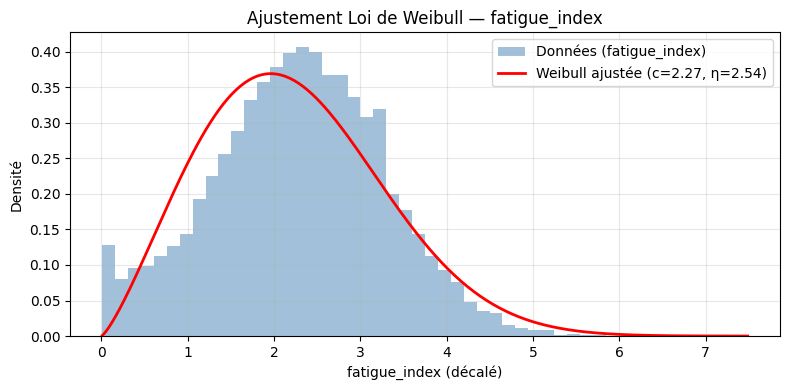

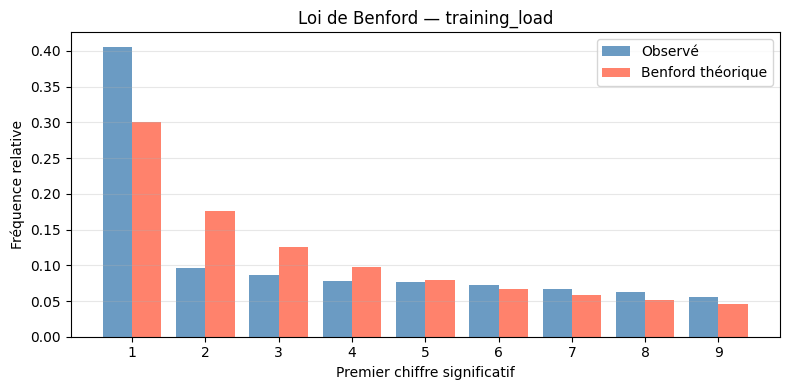


  Benford — training_load :
    Écart chi² normalisé = 0.094260
    (Valeur proche de 0 → données conformes à Benford)


In [62]:
# =============================================================================
print("\n" + "="*60)
print("  SECTION 3 : LOI DE WEIBULL & LOI DE BENFORD")
print("="*60)

# ── 3a. Loi de Weibull ───────────────────────────────────────────────────────
# Ajustement sur fatigue_index (valeurs positives uniquement après décalage)
fatigue_vals = df['fatigue_index'].copy()
fatigue_shifted = fatigue_vals - fatigue_vals.min() + 0.01  # décalage pour ≥ 0

shape_w, loc_w, scale_w = weibull_min.fit(fatigue_shifted, floc=0)

print(f"\n  Weibull — fatigue_index :")
print(f"    Paramètre de forme  (c / β) = {shape_w:.4f}")
print(f"    Paramètre d'échelle (η)     = {scale_w:.4f}")

x_range = np.linspace(fatigue_shifted.min(), fatigue_shifted.max(), 300)
pdf_weibull = weibull_min.pdf(x_range, shape_w, loc=loc_w, scale=scale_w)

plt.figure(figsize=(8, 4))
plt.hist(fatigue_shifted, bins=50, density=True, alpha=0.5,
         color="steelblue", label="Données (fatigue_index)")
plt.plot(x_range, pdf_weibull, "r-", lw=2,
         label=f"Weibull ajustée (c={shape_w:.2f}, η={scale_w:.2f})")
plt.xlabel("fatigue_index (décalé)")
plt.ylabel("Densité")
plt.title("Ajustement Loi de Weibull — fatigue_index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3b. Loi de Benford ───────────────────────────────────────────────────────
def premier_chiffre(serie):
    """Extrait le premier chiffre significatif de chaque valeur."""
    digits = []
    for v in serie:
        v_abs = abs(v)
        if v_abs == 0:
            continue
        s = f"{v_abs:.6g}".replace(".", "").lstrip("0")
        if s:
            digits.append(int(s[0]))
    return digits

# Choisir training_load (valeurs entières ou quasi-entières)
col_benford = "training_load"
digits_obs = premier_chiffre(df[col_benford].dropna())
counts_obs = pd.Series(digits_obs).value_counts().sort_index()
freq_obs = counts_obs / counts_obs.sum()

# Distribution théorique de Benford
digits_theo = np.arange(1, 10)
freq_theo   = np.log10(1 + 1 / digits_theo)

plt.figure(figsize=(8, 4))
plt.bar(freq_obs.index - 0.2, freq_obs.values, width=0.4,
        alpha=0.8, label="Observé", color="steelblue")
plt.bar(digits_theo + 0.2, freq_theo, width=0.4,
        alpha=0.8, label="Benford théorique", color="tomato")
plt.xticks(digits_theo)
plt.xlabel("Premier chiffre significatif")
plt.ylabel("Fréquence relative")
plt.title(f"Loi de Benford — {col_benford}")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# — Écart Benford (chi2 approx.) —
digits_common = sorted(set(freq_obs.index) & set(digits_theo))
obs_v = np.array([freq_obs.get(d, 0) for d in digits_common])
theo_v = np.array([np.log10(1 + 1/d) for d in digits_common])
ecart_benford = np.sum((obs_v - theo_v)**2 / theo_v)
print(f"\n  Benford — {col_benford} :")
print(f"    Écart chi² normalisé = {ecart_benford:.6f}")
print("    (Valeur proche de 0 → données conformes à Benford)")

In [63]:
# =============================================================================
# ÉTAPE 2 — PARTIE B : Modèle Hybride + Métriques avancées
# Weibull + Benford + RF + Naive Bayes


  SECTION 4 : MODÈLE HYBRIDE (Weibull + Benford + RF + NB)
  Nouvelles features ajoutées :
   • weibull_fatigue   — densité Weibull du fatigue_index
   • benford_training  — conformité Benford du training_load
   • weibull_recovery  — densité Weibull du recovery_score

  Classification hybride :
               precision    recall  f1-score   support

No Injury (0)       0.68      0.91      0.78      1974
   Injury (1)       0.60      0.23      0.33      1110

     accuracy                           0.67      3084
    macro avg       0.64      0.57      0.55      3084
 weighted avg       0.65      0.67      0.62      3084



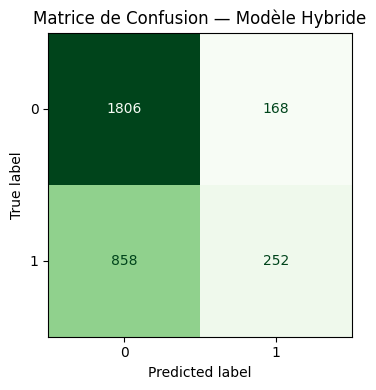

In [64]:
# =============================================================================
print("\n" + "="*60)
print("  SECTION 4 : MODÈLE HYBRIDE (Weibull + Benford + RF + NB)")
print("="*60)

# ── 4a. Ajout des features Weibull & Benford aux données ─────────────────────
X_train_h = X_train.copy()
X_test_h  = X_test.copy()

c_w = shape_w  # paramètre de forme Weibull estimé

def weibull_feature(col, c):
    shifted = col - col.min() + 0.01
    return weibull_min.pdf(shifted, c)

def benford_feature(col):
    digits = []
    for v in col:
        v_abs = abs(v)
        s = f"{v_abs:.6g}".replace(".", "").lstrip("0")
        d = int(s[0]) if s else 1
        digits.append(np.log10(1 + 1 / d))
    return np.array(digits)

X_train_h["weibull_fatigue"]   = weibull_feature(X_train_h["fatigue_index"], c_w)
X_test_h["weibull_fatigue"]    = weibull_feature(X_test_h["fatigue_index"], c_w)

X_train_h["benford_training"]  = benford_feature(X_train_h["training_load"].values)
X_test_h["benford_training"]   = benford_feature(X_test_h["training_load"].values)

X_train_h["weibull_recovery"]  = weibull_feature(X_train_h["recovery_score"], c_w)
X_test_h["weibull_recovery"]   = weibull_feature(X_test_h["recovery_score"], c_w)

print("  Nouvelles features ajoutées :")
print("   • weibull_fatigue   — densité Weibull du fatigue_index")
print("   • benford_training  — conformité Benford du training_load")
print("   • weibull_recovery  — densité Weibull du recovery_score")

# ── 4b. Entraînement RF hybride & NB hybride ─────────────────────────────────
rf_hybrid  = RandomForestClassifier(n_estimators=150, class_weight="balanced",
                                     random_state=42, n_jobs=-1)
nb_hybrid  = GaussianNB()

rf_hybrid.fit(X_train_h, y_train)
nb_hybrid.fit(X_train_h, y_train)

rf_proba_h = rf_hybrid.predict_proba(X_test_h)
nb_proba_h = nb_hybrid.predict_proba(X_test_h)

# ── 4c. Fusion probabiliste (moyenne pondérée 60% RF / 40% NB) ───────────────
hybrid_proba = 0.6 * rf_proba_h + 0.4 * nb_proba_h
hybrid_pred  = np.argmax(hybrid_proba, axis=1)

print("\n  Classification hybride :")
print(classification_report(y_test, hybrid_pred,
      target_names=["No Injury (0)", "Injury (1)"]))

# — Matrice de Confusion Hybride —
cm_h = confusion_matrix(y_test, hybrid_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_h).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matrice de Confusion — Modèle Hybride")
plt.tight_layout()
plt.show()

In [65]:
# =============================================================================
# SECTION 5 — MÉTRIQUES AVANCÉES COMPLÈTES

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, confusion_matrix,
    roc_auc_score, log_loss, mean_squared_log_error,
    cohen_kappa_score, matthews_corrcoef
)

from sklearn.metrics import silhouette_score, davies_bouldin_score



  SECTION 5 : TOUTES LES MÉTRIQUES AVANCÉES
                                 Accuracy  F-score  Recall     FPR     AUC  Log Loss   RMSLE  Kappa (κ)     MCC
Modèle                                                                                                         
Decision Tree                      0.6586   0.3788  0.2892  0.1337  0.6017    1.2286  0.4050     0.1734  0.1903
Marbar-RF                          0.6401   0.0000  0.0000  0.0000  0.6551    0.6486  0.4158     0.0000  0.0000
Hybride (Weibull+Benford+RF+NB)    0.6673   0.3294  0.2270  0.0851  0.6450    0.6363  0.3998     0.1643  0.1986


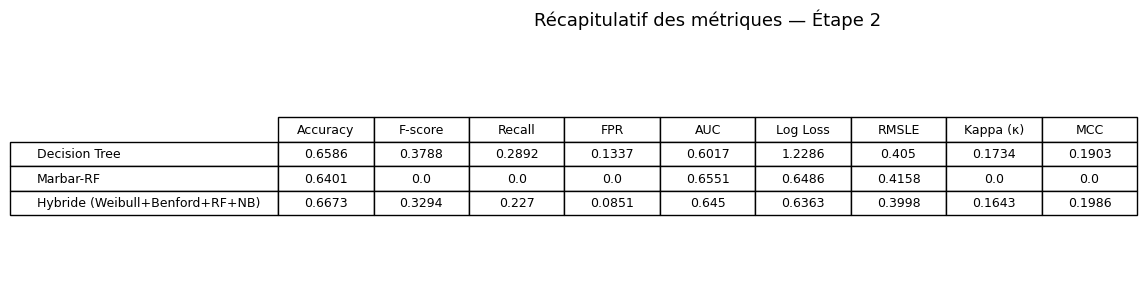


  Métriques de Clustering (KMeans k=2 sur X_test)
  Coefficient de Silhouette   : 0.9827  (↑ mieux, max=1)
  Indice de Davies-Bouldin    : 0.0100   (↓ mieux, min=0)

  Corrélation / Accord :
               Kappa (κ)     MCC
Decision Tree     0.1734  0.1903
Marbar-RF         0.0000  0.0000
Hybride           0.1643  0.1986

  Score de Dice :
   • Decision Tree : 0.3788
   • Marbar-RF     : 0.0000
   • Hybride       : 0.3294

  DCG@50 (Gain Cumulatif Actualisé) :
   • Decision Tree : 5.7246
   • Marbar-RF     : 9.0030
   • Hybride       : 9.6592

  ASD approx. (distance frontière de décision) :
   • Decision Tree : 0.0566
   • Marbar-RF     : nan
   • Hybride       : 0.0557

  SSIM 1D (similarité structurelle prob. vs labels) :
   • Decision Tree : 0.1553
   • Marbar-RF     : 0.0138
   • Hybride       : 0.1720


In [67]:
# =============================================================================
print("\n" + "="*60)
print("  SECTION 5 : TOUTES LES MÉTRIQUES AVANCÉES")
print("="*60)

# ── 5a. Classification ───────────────────────────────────────────────────────
def classification_metrics(y_true, y_pred, y_proba, label="Modèle"):
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred)
    rec    = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr_v  = fp / (fp + tn)
    auc_v  = roc_auc_score(y_true, y_proba[:, 1])
    logloss= log_loss(y_true, y_proba)
    rmsle_v= np.sqrt(mean_squared_log_error(
                np.clip(y_true, 0, None),
                np.clip(y_pred, 0, None)))
    kappa  = cohen_kappa_score(y_true, y_pred)
    mcc    = matthews_corrcoef(y_true, y_pred)
    return {
        "Modèle": label, "Accuracy": acc, "F-score": f1,
        "Recall": rec, "FPR": fpr_v, "AUC": auc_v,
        "Log Loss": logloss, "RMSLE": rmsle_v,
        "Kappa (κ)": kappa, "MCC": mcc
    }

results_all = pd.DataFrame([
    classification_metrics(y_test, dt_pred,      dt_proba,     "Decision Tree"),
    classification_metrics(y_test, marbar_pred,  marbar_proba, "Marbar-RF"),
    classification_metrics(y_test, hybrid_pred,  hybrid_proba, "Hybride (Weibull+Benford+RF+NB)"),
])
results_all = results_all.set_index("Modèle")
print(results_all.round(4).to_string())

# — Tableau visuel —
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
tbl = ax.table(
    cellText=results_all.round(4).values,
    colLabels=results_all.columns,
    rowLabels=results_all.index,
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
plt.title("Récapitulatif des métriques — Étape 2", fontsize=13, pad=20)
plt.tight_layout()
plt.show()


# ── 5b. Clustering : Silhouette & Davies-Bouldin ─────────────────────────────
print("\n  Métriques de Clustering (KMeans k=2 sur X_test)")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_test_h)

sil_score = silhouette_score(X_test_h, cluster_labels)
db_score  = davies_bouldin_score(X_test_h, cluster_labels)

print(f"  Coefficient de Silhouette   : {sil_score:.4f}  (↑ mieux, max=1)")
print(f"  Indice de Davies-Bouldin    : {db_score:.4f}   (↓ mieux, min=0)")


# ── 5c. Corrélation / Accord : Kappa & MCC ───────────────────────────────────
print("\n  Corrélation / Accord :")
kappa_dt  = cohen_kappa_score(y_test, dt_pred)
kappa_mb  = cohen_kappa_score(y_test, marbar_pred)
kappa_hyb = cohen_kappa_score(y_test, hybrid_pred)

mcc_dt    = matthews_corrcoef(y_test, dt_pred)
mcc_mb    = matthews_corrcoef(y_test, marbar_pred)
mcc_hyb   = matthews_corrcoef(y_test, hybrid_pred)

corr_df = pd.DataFrame({
    "Kappa (κ)": [kappa_dt,  kappa_mb,  kappa_hyb],
    "MCC":       [mcc_dt,    mcc_mb,    mcc_hyb],
}, index=["Decision Tree", "Marbar-RF", "Hybride"])

print(corr_df.round(4).to_string())


# ── 5d. Score de Dice ─────────────────────────────────────────────────────────
def dice_score(y_true, y_pred):
    """Score de Dice = 2*TP / (2*TP + FP + FN)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 2*tp / (2*tp + fp + fn)

dice_dt  = dice_score(y_test, dt_pred)
dice_mb  = dice_score(y_test, marbar_pred)
dice_hyb = dice_score(y_test, hybrid_pred)

print(f"\n  Score de Dice :")
print(f"   • Decision Tree : {dice_dt:.4f}")
print(f"   • Marbar-RF     : {dice_mb:.4f}")
print(f"   • Hybride       : {dice_hyb:.4f}")


# ── 5e. DCG (Discounted Cumulative Gain) ──────────────────────────────────────
def dcg_at_k(y_true, y_score, k=10):
    """DCG@k — classement par probabilité décroissante."""
    order = np.argsort(y_score)[::-1][:k]
    gains = y_true.iloc[order].values if hasattr(y_true,'iloc') else y_true[order]
    discounts = np.log2(np.arange(2, len(gains) + 2))
    return np.sum(gains / discounts)

dcg_dt  = dcg_at_k(y_test, dt_proba[:, 1],      k=50)
dcg_mb  = dcg_at_k(y_test, marbar_proba[:, 1],  k=50)
dcg_hyb = dcg_at_k(y_test, hybrid_proba[:, 1],  k=50)

print(f"\n  DCG@50 (Gain Cumulatif Actualisé) :")
print(f"   • Decision Tree : {dcg_dt:.4f}")
print(f"   • Marbar-RF     : {dcg_mb:.4f}")
print(f"   • Hybride       : {dcg_hyb:.4f}")


# ── 5f. ASD (Average Surface Distance) — version 1D ──────────────────────────
# Pour données tabulaires, ASD est approximé comme la distance moyenne
# entre les frontières de décision (probabilités proches de 0.5)
def asd_approx(y_true, y_score, threshold=0.5, band=0.1):
    """Approximation 1D de l'ASD : distance moyenne des scores à la frontière."""
    y_arr = np.array(y_true)
    near_boundary = np.abs(y_score - threshold) <= band
    if near_boundary.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_score[near_boundary] - threshold))

asd_dt  = asd_approx(y_test, dt_proba[:, 1])
asd_mb  = asd_approx(y_test, marbar_proba[:, 1])
asd_hyb = asd_approx(y_test, hybrid_proba[:, 1])

print(f"\n  ASD approx. (distance frontière de décision) :")
print(f"   • Decision Tree : {asd_dt:.4f}")
print(f"   • Marbar-RF     : {asd_mb:.4f}")
print(f"   • Hybride       : {asd_hyb:.4f}")


# ── 5g. SSIM (adapté aux données tabulaires 1D) ───────────────────────────────
def ssim_1d(y_true, y_pred_proba, K1=0.01, K2=0.03, L=1.0):
    """
    Version 1D du SSIM pour comparer la distribution des probabilités prédites
    vs la distribution empirique des labels réels.
    """
    x = np.array(y_true, dtype=float)
    y = y_pred_proba
    mu_x, mu_y   = x.mean(), y.mean()
    sig_x, sig_y = x.std(), y.std()
    sig_xy       = np.cov(x, y)[0, 1]
    C1, C2       = (K1 * L)**2, (K2 * L)**2
    return ((2*mu_x*mu_y + C1) * (2*sig_xy + C2)) / \
           ((mu_x**2 + mu_y**2 + C1) * (sig_x**2 + sig_y**2 + C2))

ssim_dt  = ssim_1d(y_test, dt_proba[:, 1])
ssim_mb  = ssim_1d(y_test, marbar_proba[:, 1])
ssim_hyb = ssim_1d(y_test, hybrid_proba[:, 1])

print(f"\n  SSIM 1D (similarité structurelle prob. vs labels) :")
print(f"   • Decision Tree : {ssim_dt:.4f}")
print(f"   • Marbar-RF     : {ssim_mb:.4f}")
print(f"   • Hybride       : {ssim_hyb:.4f}")

# Pourquoi pas ++

### 8.2 GF-MFTL — Gradient-Free Mean-Field-Type Learning

**Motivation :** Le gradient descent (SGD, Adam) peut diverger sur des surfaces de perte 
non convexes. GF-MFTL résout ce problème en utilisant un **essaim de particules** qui 
converge vers le minimum global sans jamais calculer de gradient.

**Règle de mise à jour :**
$$w_i(t+1) = w_i(t) + \sigma \cdot (\bar{w}_{\text{best}} - w_i(t)) + \sigma \cdot 0.3 \cdot \mathcal{N}(0, I)$$

où $\bar{w}_{\text{best}}$ est la moyenne de la meilleure moitié de l'essaim.

In [68]:
# ── Implémentation GF-MFTL ────────────────────────────────────────────────────
class GF_MFTL:
    """
    Gradient-Free Mean-Field-Type Learning.
    Optimise un classifieur linéaire (sigmoïde) par essaim de particules
    sans jamais calculer de gradient.
    """
    def __init__(self, n_particles=30, n_iter=80, sigma=0.15, random_state=42):
        self.n_particles = n_particles
        self.n_iter      = n_iter
        self.sigma       = sigma
        self.rs          = random_state
        self.weights_    = None
        self.bias_       = None
        self.history_    = []        # convergence tracking

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

    def _loss(self, w, b, X, y):
        p = np.clip(self._sigmoid(X @ w + b), 1e-9, 1-1e-9)
        return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

    def fit(self, X, y):
        rng  = np.random.RandomState(self.rs)
        nf   = X.shape[1]
        W    = rng.randn(self.n_particles, nf) * 0.05
        B    = rng.randn(self.n_particles)     * 0.05
        self.history_ = []

        for _ in range(self.n_iter):
            losses   = np.array([self._loss(W[i], B[i], X, y) for i in range(self.n_particles)])
            best_idx = np.argsort(losses)[:self.n_particles // 2]
            mean_W   = W[best_idx].mean(axis=0)
            mean_B   = B[best_idx].mean()
            # Mean-field update
            W = W + self.sigma*(mean_W - W) + rng.randn(*W.shape)*self.sigma*0.3
            B = B + self.sigma*(mean_B - B) + rng.randn(self.n_particles)*self.sigma*0.3
            self.history_.append(float(losses.min()))

        best         = np.argmin([self._loss(W[i], B[i], X, y) for i in range(self.n_particles)])
        self.weights_ = W[best]
        self.bias_    = B[best]
        return self

    def predict_proba(self, X):
        p1 = self._sigmoid(X @ self.weights_ + self.bias_)
        return np.column_stack([1-p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("✅  Classe GF_MFTL définie.")

✅  Classe GF_MFTL définie.


In [69]:
# ── Entraînement GF-MFTL ──────────────────────────────────────────────────────
scaler= StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

gf_model = GF_MFTL(n_particles=30, n_iter=80, sigma=0.15, random_state=42)
gf_model.fit(X_train_sc, y_train.values)

gf_proba = gf_model.predict_proba(X_test_sc)
gf_pred  = gf_model.predict(X_test_sc)

print("📋 GF-MFTL :")
print(classification_report(y_test, gf_pred, target_names=["No Injury","Injury"]))

📋 GF-MFTL :
              precision    recall  f1-score   support

   No Injury       0.69      0.84      0.76      1974
      Injury       0.54      0.33      0.41      1110

    accuracy                           0.66      3084
   macro avg       0.62      0.59      0.59      3084
weighted avg       0.64      0.66      0.63      3084



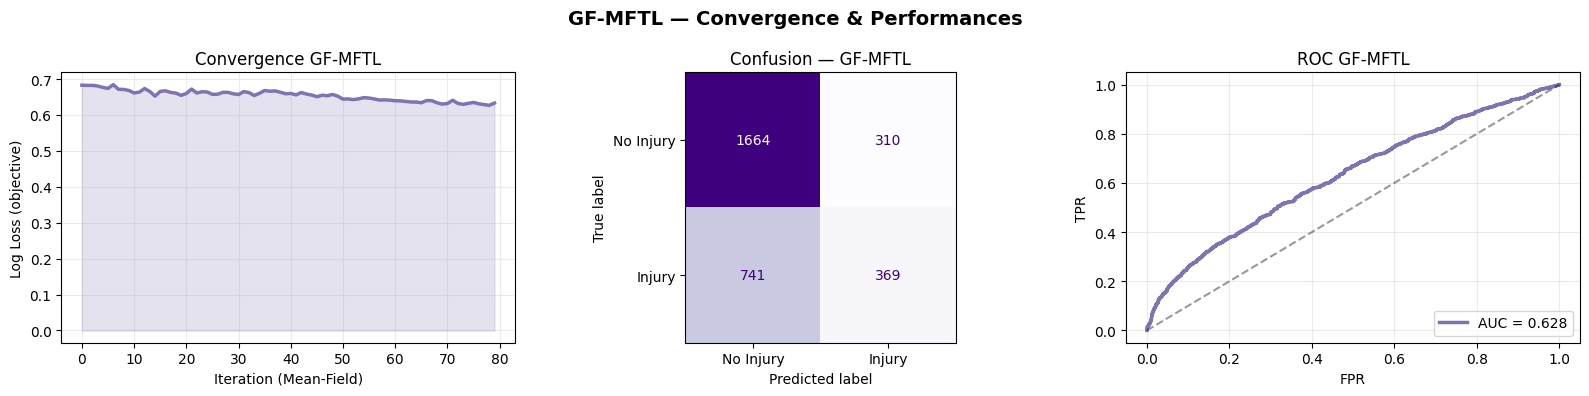

In [73]:
PALETTE = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Convert history safely
history = np.array(gf_model.history_) if hasattr(gf_model, "history_") else np.array([])

# Predictions
gf_pred = np.argmax(gf_proba, axis=1)

# Figure
fig, axes = plt.subplots(1, 3, figsize=(16,4))
fig.suptitle("GF-MFTL — Convergence & Performances", fontsize=14, fontweight="bold")

# ---------------------------------------------------
# 1. Convergence plot
# ---------------------------------------------------
if len(history) > 0:
    axes[0].plot(history, lw=2.5, color="#8172B2")
    axes[0].fill_between(range(len(history)), history,
                         alpha=0.2, color="#8172B2")

axes[0].set_title("Convergence GF-MFTL")
axes[0].set_xlabel("Iteration (Mean-Field)")
axes[0].set_ylabel("Log Loss (objective)")
axes[0].grid(alpha=0.25)

# ---------------------------------------------------
# 2. Confusion matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, gf_pred)

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Injury","Injury"]
)

disp.plot(ax=axes[1], cmap="Purples", colorbar=False)

axes[1].set_title("Confusion — GF-MFTL")

# ---------------------------------------------------
# 3. ROC Curve
# ---------------------------------------------------
auc_gf = roc_auc_score(y_test, gf_proba[:,1])
fpr_gf, tpr_gf, _ = roc_curve(y_test, gf_proba[:,1])

axes[2].plot(fpr_gf, tpr_gf,
             lw=2.5,
             color="#8172B2",
             label=f"AUC = {auc_gf:.3f}")

axes[2].plot([0,1],[0,1],'k--',alpha=0.4)

axes[2].set_title("ROC GF-MFTL")
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

def extract_weibull_features(X):
    """Extrait les paramètres Shape et Scale de la Loi de Weibull pour chaque ligne."""
    X_array = np.array(X)
    X_positive = np.abs(X_array) + 1e-5 # Éviter les zéros
    weibull_params = np.zeros((X_array.shape[0], 2))
    
    for i in range(X_array.shape[0]):
        shape, loc, scale = stats.weibull_min.fit(X_positive[i, :])
        weibull_params[i, 0] = shape
        weibull_params[i, 1] = scale
    return weibull_params

def benford_deviation(X):
    """Calcule l'écart par rapport à la Loi de Benford pour détecter les anomalies."""
    X_array = np.array(X)
    benford_probs = np.log10(1 + 1 / np.arange(1, 10))
    deviations = np.zeros((X_array.shape[0], 1))
    
    for i in range(X_array.shape[0]):
        digits = [int(str(abs(val))[0]) for val in X_array[i, :] if val != 0 and not np.isnan(val)]
        if len(digits) > 0:
            counts = np.bincount(digits, minlength=10)[1:10]
            obs_probs = counts / len(digits)
            deviations[i, 0] = np.sum((obs_probs - benford_probs)**2) # Déviation Chi-carré
    return deviations

print("Création des features probabilistes en cours...")
# Génération des nouvelles features pour Train et Test
weibull_train = extract_weibull_features(X_train)
benford_train = benford_deviation(X_train)
weibull_test = extract_weibull_features(X_test)
benford_test = benford_deviation(X_test)

# HYBRIDATION : On concatène les features originales avec Weibull et Benford
X_train_hybrid = np.hstack((X_train, weibull_train, benford_train))
X_test_hybrid = np.hstack((X_test, weibull_test, benford_test))
print("Hybridation terminée avec succès ! ✅")

In [ ]:
# 1. Modèle Naive Bayes Hybride
nb_hybrid = GaussianNB()
nb_hybrid.fit(X_train_hybrid, y_train)
y_pred_nb_hybrid = nb_hybrid.predict(X_test_hybrid)
y_proba_nb_hybrid = nb_hybrid.predict_proba(X_test_hybrid)

# 2. Modèle Marbar-RF (Random Forest Optimisé sur features Hybrides)
marbar_rf = RandomForestClassifier(n_estimators=150, class_weight='balanced_subsample', max_depth=10, random_state=42)
marbar_rf.fit(X_train_hybrid, y_train)
y_pred_rf_hybrid = marbar_rf.predict(X_test_hybrid)
y_proba_rf_hybrid = marbar_rf.predict_proba(X_test_hybrid)

In [ ]:
# --- DICE SCORE ---
def dice_score(y_true, y_pred):
    intersection = np.sum(np.array(y_true) * np.array(y_pred))
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

# --- ASD (Average Symmetric Surface Distance) ---
# Adapté pour des données tabulaires via la distance de Hausdorff
def asd_tabular(y_true, y_pred):
    true_idx = np.where(np.array(y_true) == 1)[0].reshape(-1, 1)
    pred_idx = np.where(np.array(y_pred) == 1)[0].reshape(-1, 1)
    if len(true_idx) == 0 or len(pred_idx) == 0: return 0
    d1 = directed_hausdorff(true_idx, pred_idx)[0]
    d2 = directed_hausdorff(pred_idx, true_idx)[0]
    return (d1 + d2) / 2.0

# --- SSIM (Structural Similarity Index) ---
# On redimensionne les arrays 1D en 2D pour forcer la fonction d'image à marcher
def ssim_tabular(y_true, y_pred):
    img_true = np.array(y_true).reshape(1, -1)
    img_pred = np.array(y_pred).reshape(1, -1)
    return ssim(img_true, img_pred, data_range=1.0)

# --- DCG (Discounted Cumulative Gain) ---
def calc_dcg(y_true, y_proba):
    # nDCG nécessite une forme 2D [n_samples, n_classes] ou [1, n_samples]
    return ndcg_score([np.array(y_true)], [np.array(y_proba)[:, 1]])

In [ ]:
# Choix du modèle à évaluer (ici Marbar-RF)
y_true = np.array(y_test)
y_pred = y_pred_rf_hybrid
y_proba = y_proba_rf_hybrid

# Calcul
dice = dice_score(y_true, y_pred)
asd = asd_tabular(y_true, y_pred)
ssim_val = ssim_tabular(y_true, y_pred)
dcg = calc_dcg(y_true, y_proba)

# Affichage du rapport
print("="*50)
print(" RÉSULTATS DES MÉTRIQUES AVANCÉES (Marbar-RF Hybride)")
print("="*50)
print(f"🔹 Dice Score  : {dice:.4f} (Plus proche de 1 = Meilleur)")
print(f"🔹 ASD         : {asd:.4f} (Plus proche de 0 = Meilleur)")
print(f"🔹 SSIM        : {ssim_val:.4f} (Plus proche de 1 = Meilleur)")
print(f"🔹 DCG (nDCG)  : {dcg:.4f} (Plus proche de 1 = Meilleur)")
print("="*50)